# Refine NK-cell states in the AL bone marrow

**Biology rationale.** NK cells receive inhibitory non-classical MHC-I and prostaglandin signals implicated in suboptimal response.

**Aim.** Subset and annotate NK-cell populations and assess their abundance and functional states.

**Data input.** `sce1_nkcell.rds`, `FigS11a.pdf`, `FigS11b.pdf`, `NKcell.noverlabel.csv`, `Fig6i.pdf`



**Data outputs.** `ALL_boxplots_by_celltype_good_poor.pdf`, `saved_plot_files.csv`, `ALL_boxplots_by_celltype_pre_post_genes_columns_groups_rows.pdf`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1_nkcell<-readRDS(file='sce1_nkcell.rds')

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


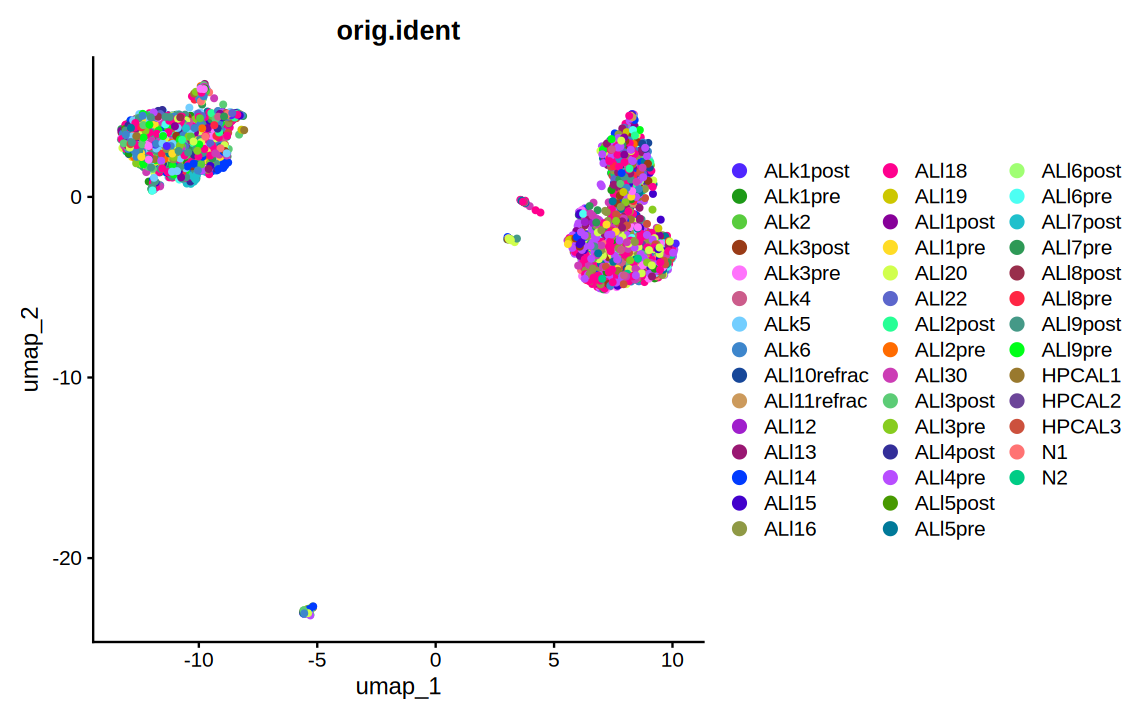

In [3]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_nkcell, pt.size=1,reduction = "umap", group.by = c("orig.ident"),label=F) 

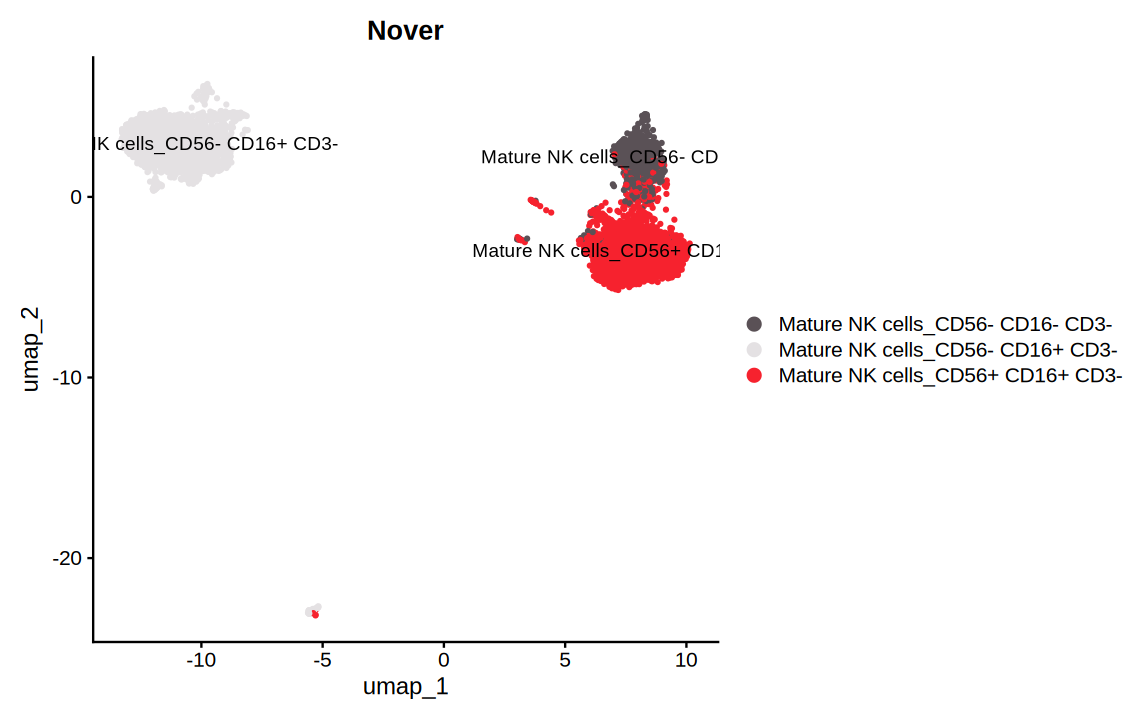

In [4]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_nkcell, pt.size=0.5,reduction = "umap", group.by = c("Nover"),label=T) 

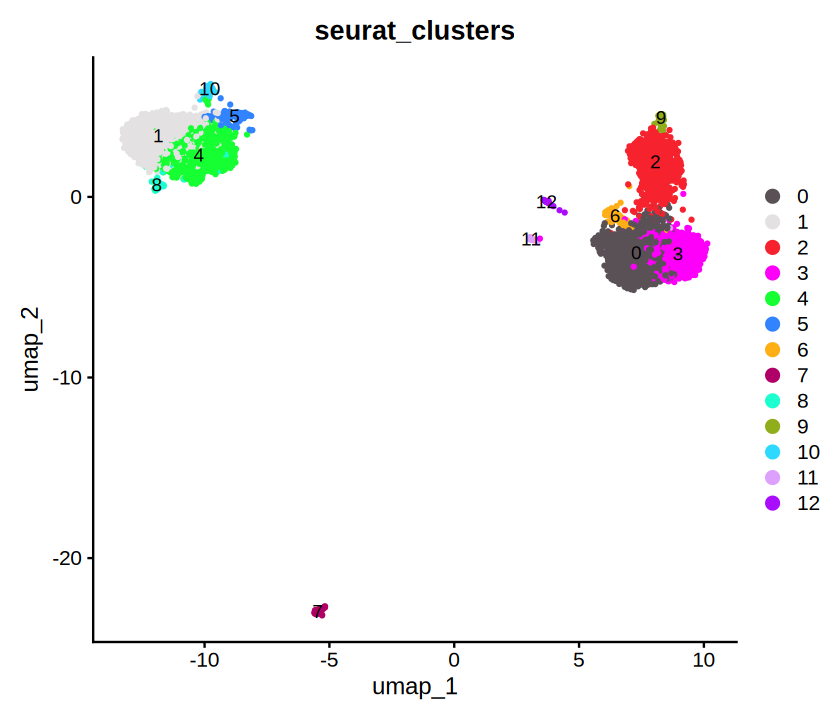

In [5]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=7)
DimPlot_scCustom(sce1_nkcell, pt.size=0.5,reduction = "umap", group.by = c("seurat_clusters"),label=T) 

## 2. Cell–cell communication analysis


In [6]:
sce1_nkcell

An object of class Seurat 
36601 features across 4245 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, UMAP, harmony, umap

In [7]:
Idents(sce1_nkcell)<-'Nover'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene<- c(
"FCGR3A", "NCAM1", "NCR1",'CD3', # Canonical NK cell surface markers (CD16, CD56, NKp46,CD3)
"TCF7","SELL","IL7R","XCL1","XCL2",#immature
"FCGR3A","CX3CR1","ZEB2","KLRD1", #mature
"PDCD1", "TIGIT", "LAG3", "HAVCR2", "CD96", "TIM3", # NK cell exhaustion/inhibitory checkpoint receptors
"KLRC1", "KLRG1", "KLRD1", # Inhibitory receptors and terminal differentiation markers
"IFNG", "TNF", 'IL10',# Effector cytokines
"PRF1", "GZMB", "GZMA", # Cytotoxic
"CXCR6", "CD69", "ITGA1", # Tissue-resident
"CD38"
) 


In [8]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_nkcell, features = unique(allgene), split.by = "seurat_clusters", scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
“The following requested variables were not found: CD3, TIM3”


## 3. Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




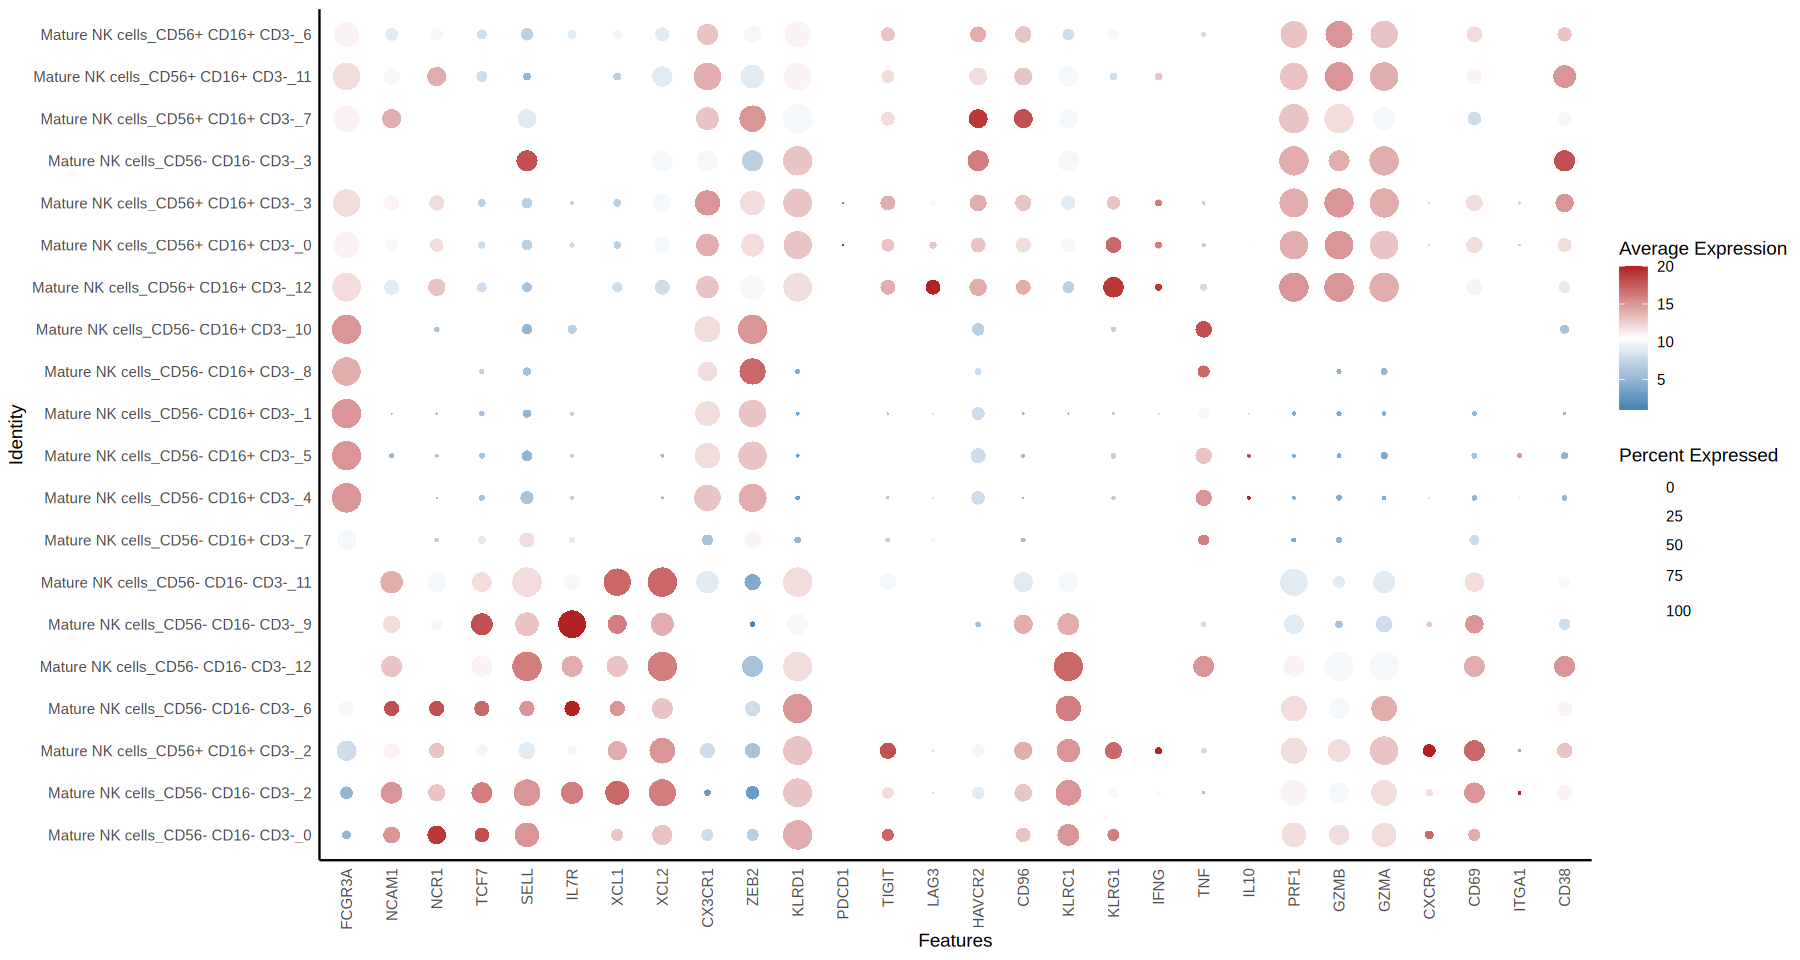

In [9]:
options(repr.plot.height=8,repr.plot.width=15)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [10]:
# Create a named vector: keys = original label, values = new label
sce1_nkcell@meta.data$Annotation<-paste(sce1_nkcell@meta.data$Nover, sce1_nkcell@meta.data$'seurat_clusters',sep='_')

replacements <- c(
  "Mature NK cells_CD56- CD16- CD3-_11" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_9" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_2" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_12" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_6" = "NK cells_CD56+_CD16-_immature",
  "Mature NK cells_CD56- CD16- CD3-_3" = "NK cells_CD56-_CD16+_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_3" = "NK cells_CD56-_CD16+_cytotoxic_terminal",
  "Mature NK cells_CD56+ CD16+ CD3-_0" = "NK cells_CD56-_CD16+_cytotoxic_terminal",
  "Mature NK cells_CD56+ CD16+ CD3-_12" = "NK cells_CD56-_CD16+_cytotoxic_terminal",
  "Mature NK cells_CD56+ CD16+ CD3-_6" = "NK cells_CD56-_CD16+_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_11" = "NK cells_CD56-_CD16+_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_7" = "NK cells_CD56+_CD16-_cytotoxic",
  "Mature NK cells_CD56+ CD16+ CD3-_2" = "NK cells_CD56+_CD16-_transitional",
  "Mature NK cells_CD56- CD16- CD3-_0" = "NK cells_CD56+_CD16-_transitional",
  "Mature NK cells_CD56- CD16+ CD3-_10" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_8" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_1" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_7" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_5" = "NK cells_CD56-_CD16+_cytokine",
  "Mature NK cells_CD56- CD16+ CD3-_4" = "NK cells_CD56-_CD16+_cytokine"
)

# Apply the replacement in one go:
sce1_nkcell@meta.data$Annotation <- replacements[sce1_nkcell@meta.data$Annotation]

# If any value not matched, return original:
sce1_nkcell@meta.data$Annotation[is.na(sce1_nkcell@meta.data$Annotation)] <- 
  paste(sce1_nkcell@meta.data$Nover, sce1_nkcell@meta.data$seurat_clusters, sep = "_")[is.na(sce1_nkcell@meta.data$Annotation)]


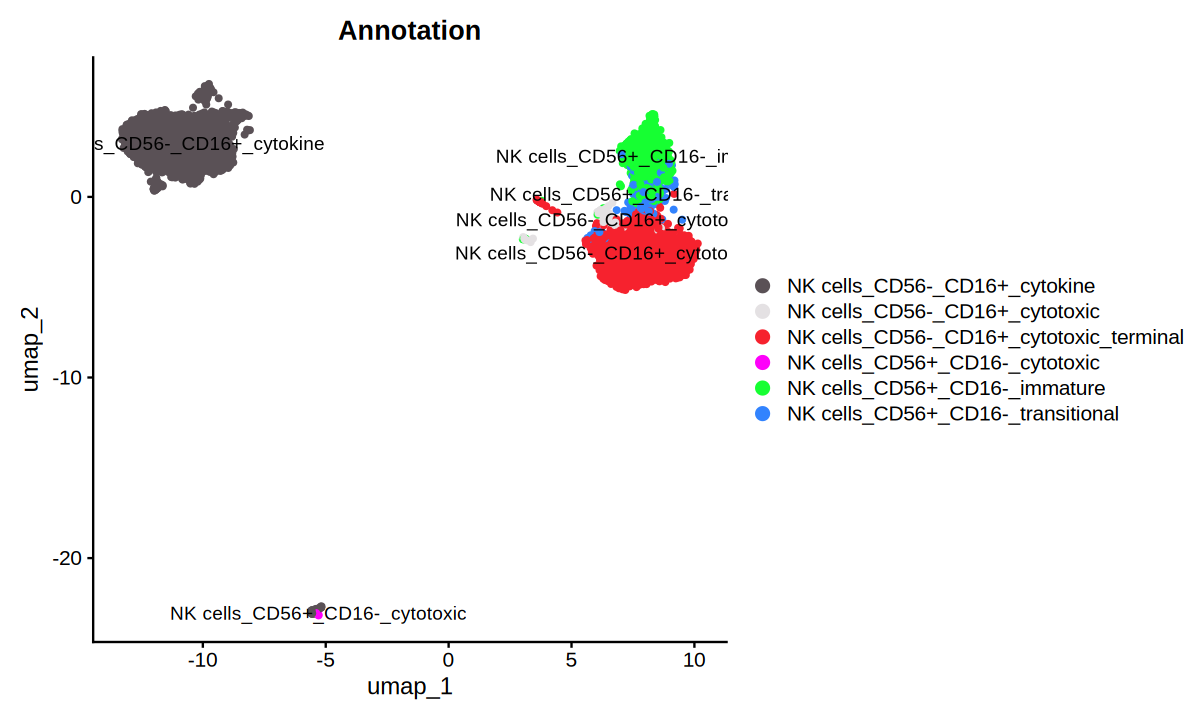

In [11]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=10)
DimPlot_scCustom(sce1_nkcell , pt.size=1,reduction = "umap", group.by = c("Annotation"),label=T) 

In [12]:
p <- DimPlot_scCustom(sce1_nkcell , pt.size=1,reduction = "umap", group.by = c("Annotation"),label=T) 
ggsave("FigS11a.pdf", plot = p, width = 10, height =6)


In [13]:
library(RColorBrewer)

Idents(sce1_nkcell)<-'Annotation'
# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_nkcell, features = unique(allgene),  scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
“The following requested variables were not found: CD3, TIM3”


## 4. Visualization and figure generation


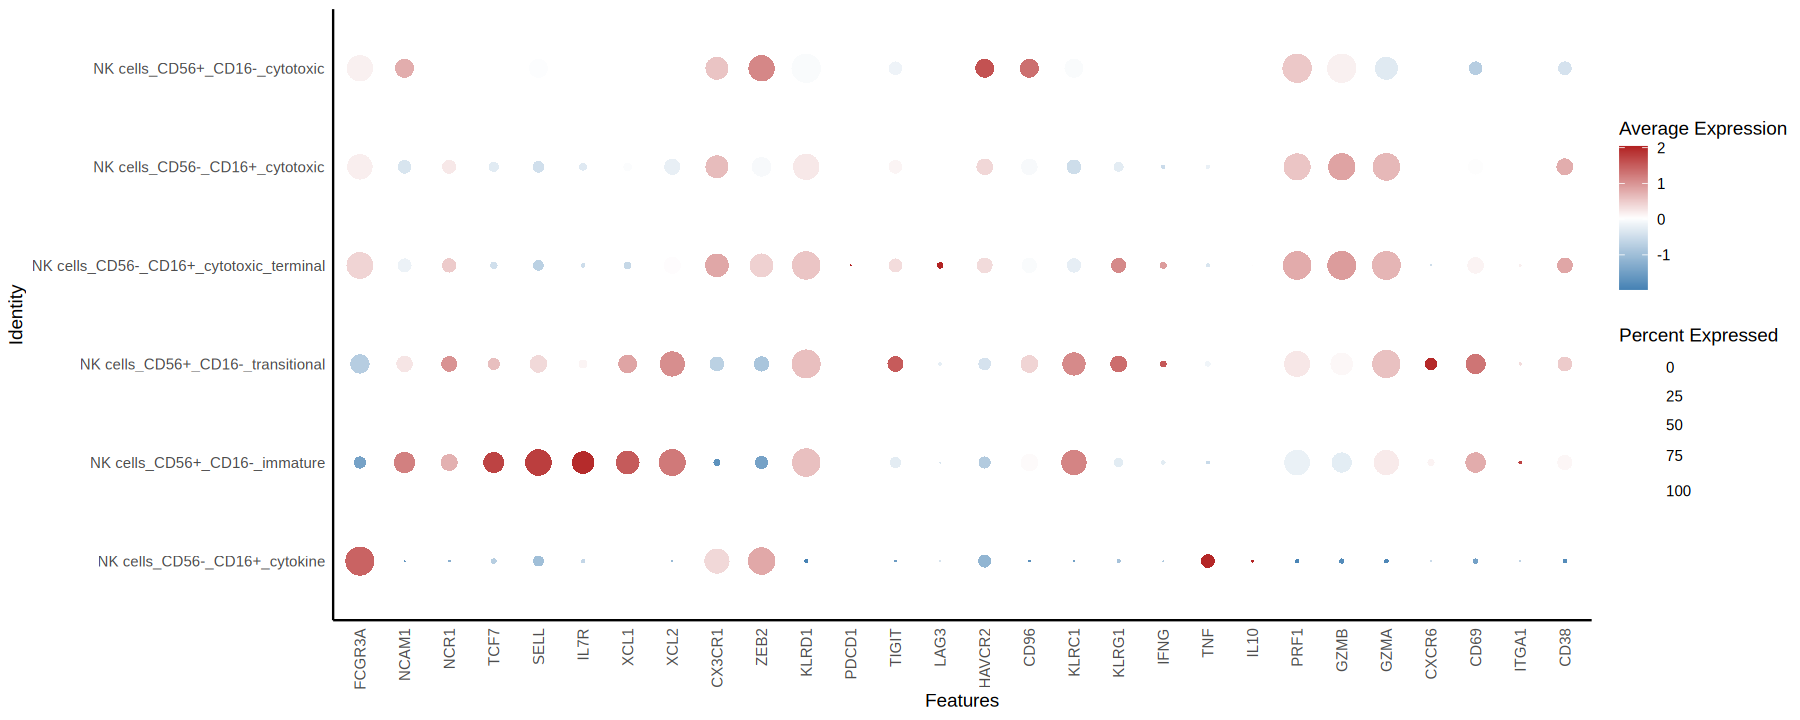

In [14]:
options(repr.plot.height=6,repr.plot.width=15)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [15]:
ggsave("FigS11b.pdf", plot = p, width = 10, height =6)

In [16]:
sce1_nkcell$label <- sce1_nkcell$orig.ident
sce1_nkcell$label <- ifelse(grepl("N1|N2", sce1_nkcell$label), "Normal", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl9pre|ALl8pre|ALl6pre|ALl30|ALl20|ALl19|ALl18|ALl14|ALl13|ALl1pre|ALk4|ALk1pre", sce1_nkcell$label), "AL_CR_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl9post|ALl8post|ALl6post|ALl1post|ALk1post", sce1_nkcell$label), "AL_CR_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl3pre|ALl22|ALk3pre|ALk2|HPCAL2", sce1_nkcell$label), "AL_VGPR_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALk3post|ALl3post", sce1_nkcell$label), "AL_VGPR_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl7pre|ALl12|ALk6|HPCAL1", sce1_nkcell$label), "AL_NR/SD_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl7post", sce1_nkcell$label), "AL_NR/SD_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl5pre|ALl4pre|ALl2pre|ALl16", sce1_nkcell$label), "AL_PR_pre", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("ALl5post|ALl4post|ALl2post|ALl11refrac|ALl10refrac", sce1_nkcell$label), "AL_PR_post", sce1_nkcell$label)
sce1_nkcell$label <- ifelse(grepl("HPCAL3|ALl15|ALk5", sce1_nkcell$label), "AL_NotRecorded", sce1_nkcell$label)

## 5. Packages and setup


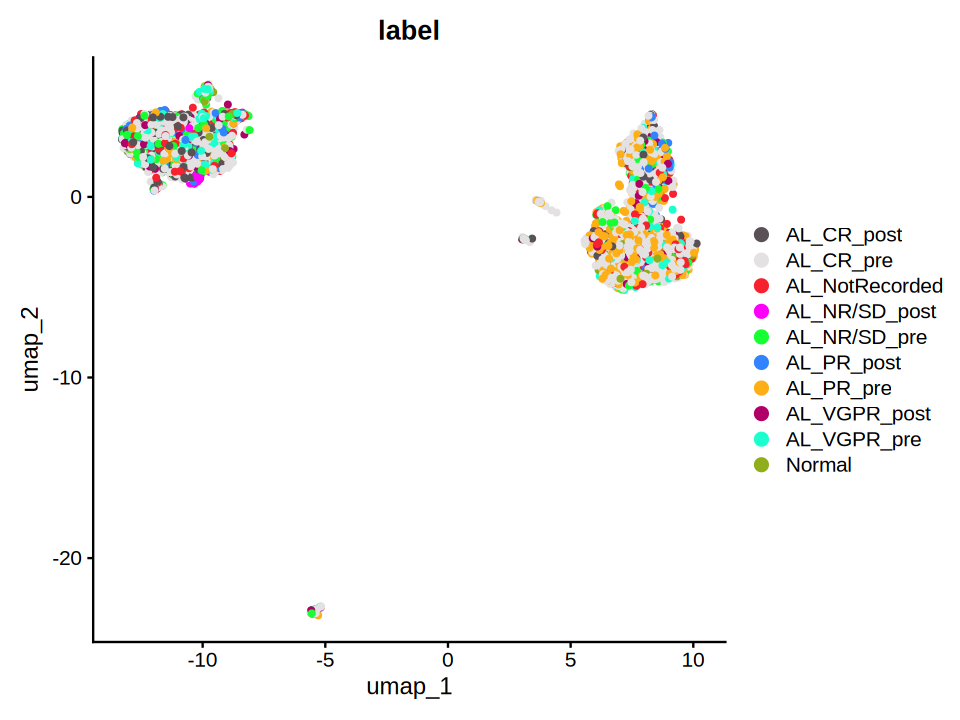

In [17]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_nkcell , pt.size=1,reduction = "umap", group.by = c("label"),label=F) 

# mismatched Pre:  0

# mismatched Post: 0

Warning message:
“There were 4 warnings in `mutate()`.
The first warning was:
ℹ In argument: `pval = ifelse(...)`.
ℹ In row 6.
Caused by warning in `chisq.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”


# A tibble: 36 × 6
   response celltype                               pre  post      pval      padj
   <fct>    <fct>                                <int> <int>     <dbl>     <dbl>
 1 AL_CR    NK cells_CD56-_CD16+_cytotoxic_term…   832    23 1.73e-168 3.98e-167
 2 AL_PR    NK cells_CD56-_CD16+_cytotoxic_term…   370     7 5.39e- 78 6.20e- 77
 3 AL_CR    NK cells_CD56-_CD16+_cytokine          613   256 9.30e- 34 7.13e- 33
 4 AL_NR/SD NK cells_CD56-_CD16+_cytokine          190    30 3.96e- 27 2.28e- 26
 5 AL_CR    NK cells_CD56+_CD16-_immature          213    45 1.33e- 25 6.12e- 25
 6 AL_NR/SD NK cells_CD56-_CD16+_cytotoxic_term…    84     2 9.38e- 19 3.59e- 18
 7 AL_PR    NK cells_CD56+_CD16-_immature          138    29 3.32e- 17 1.09e- 16
 8 AL_VGPR  NK cells_CD56-_CD16+_cytokine          228    84 3.57e- 16 1.03e- 15
 9 AL_NR/SD NK cells_CD56+_CD16-_immature           57     0 4.36e- 14 1.11e- 13
10 AL_VGPR  NK cells_CD56-_CD16+_cytotoxic_term…    88    28 2.53e-  8 5.83e-  8
11 AL_CR 

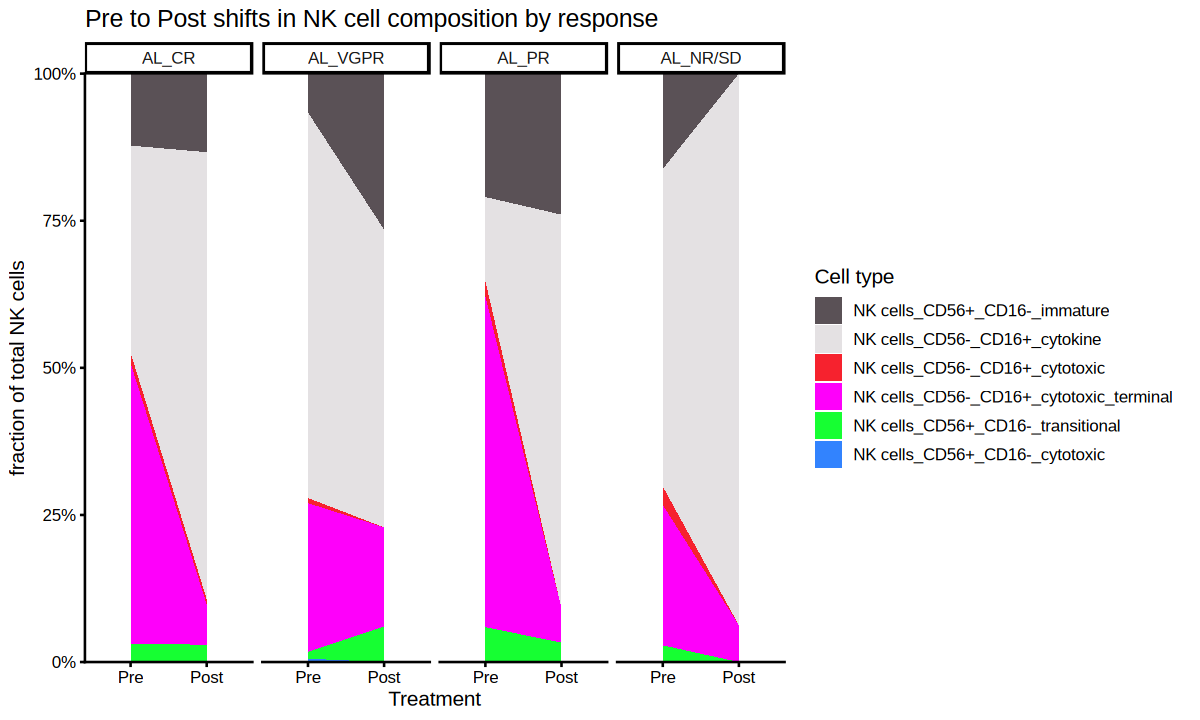

In [18]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(scCustomize)

Idents(sce1_nkcell) <- "Annotation"
ct_lvls <- levels(sce1_nkcell)
ct_cols <- setNames(
  scCustomize::DiscretePalette_scCustomize(length(ct_lvls), palette = "polychrome"),
  ct_lvls
)

# --- 0) Clean the label column (quotes, spaces, smart quotes) ---
sce1_nkcell$label <- as.character(sce1_nkcell$label)
sce1_nkcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_nkcell$label)

# --- 1) Build md with anchored matching ---
md <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label)  # defensive
  ) %>%
  transmute(
    celltype  = Annotation,
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ "Other"
    ),
    label_clean = label_clean
  )

# --- 2) Sanity checks ---
# Any cells flagged as Pre that do NOT end with _pre ?
bad_pre  <- md %>% filter(treatment == "Pre"  & !grepl("(_pre)$",  label_clean, perl = TRUE))
bad_post <- md %>% filter(treatment == "Post" & !grepl("(_post)$", label_clean, perl = TRUE))
message("# mismatched Pre:  ", nrow(bad_pre))
message("# mismatched Post: ", nrow(bad_post))
# If you see non-zero here, print some examples:
if (nrow(bad_pre) > 0 || nrow(bad_post) > 0) {
  print(head(unique(c(bad_pre$label_clean, bad_post$label_clean)), 10))
}

# --- 3) Composition per response × treatment (as before) ---
comp <- md %>%
  count(response, treatment, celltype, name = "n") %>%
  group_by(response, treatment) %>%
  mutate(frac = n / sum(n)) %>%
  ungroup() %>%
  complete(response, treatment, celltype, fill = list(n = 0, frac = 0))

comp$celltype  <- factor(comp$celltype,  levels = ct_lvls)
comp$treatment <- factor(comp$treatment, levels = c("Pre","Post","Other"))

# --- 4) Plot (skip Normal and AL_NotRecorded only in the plot) ---
options(repr.plot.height = 6, repr.plot.width = 10)

# Force the facet order
comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","AL_NotRecorded","Normal"))

p <- ggplot(
  comp %>%
    filter(treatment %in% c("Pre", "Post"),
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = treatment, y = frac, fill = celltype, group = celltype)
) +
  geom_area(stat = "identity", position = "stack") +
  facet_wrap(~response, nrow = 1) +   # one row, fixed order
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  labs(y = "fraction of total NK cells", x = "Treatment", fill = "Cell type",
       title = "Pre to Post shifts in NK cell composition by response") +
  scale_fill_manual(values = ct_cols) +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p)



# --- 5) Stats (unchanged) ---
chisq_results <- comp %>%
  filter(treatment %in% c("Pre","Post")) %>%
  group_by(response, celltype) %>%
  summarise(
    pre  = sum(n[treatment == "Pre"]),
    post = sum(n[treatment == "Post"]),
    .groups="drop"
  ) %>%
  rowwise() %>%
  mutate(pval = ifelse((pre+post) > 0,
                       chisq.test(c(pre, post), p = c(0.5, 0.5))$p.value,
                       NA_real_)) %>%
  ungroup() %>%
  mutate(padj = p.adjust(pval, method="BH")) %>%
  arrange(padj)

chisq_results %>% print(n = 20)


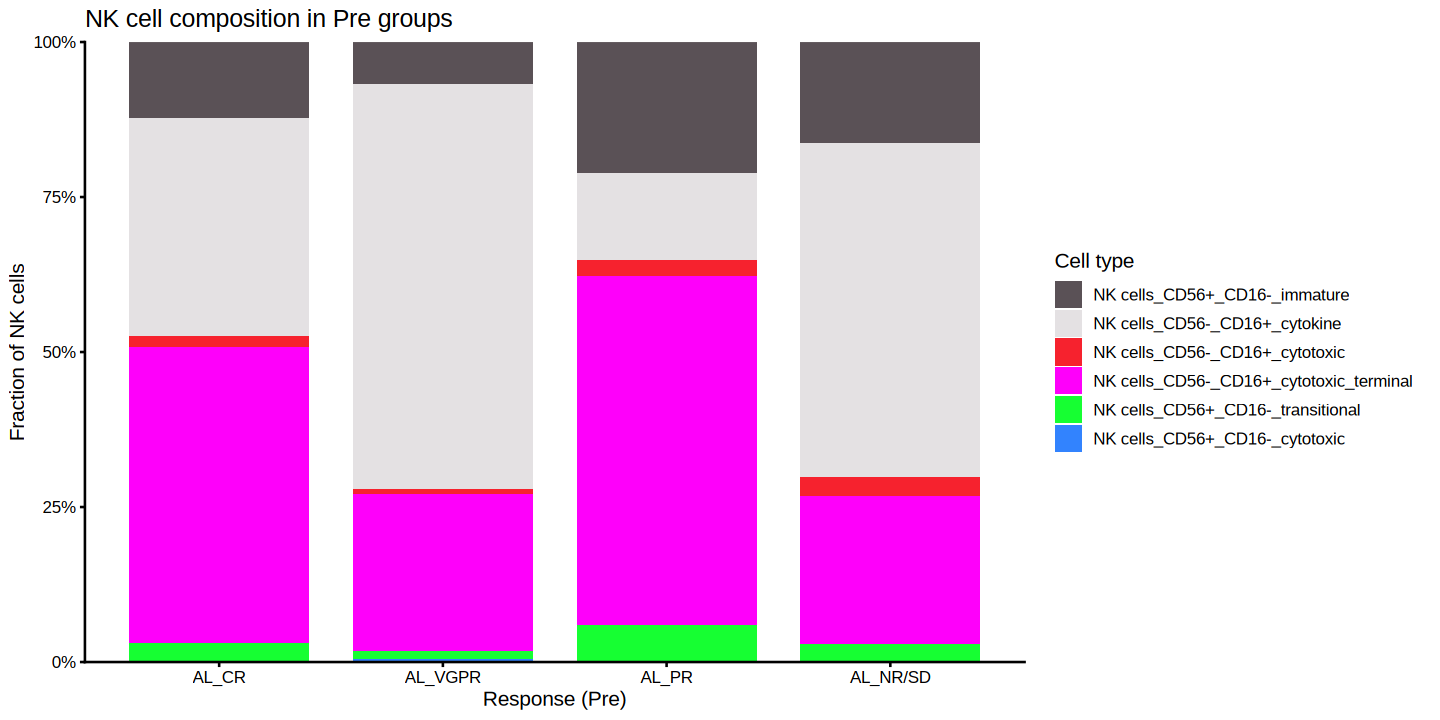

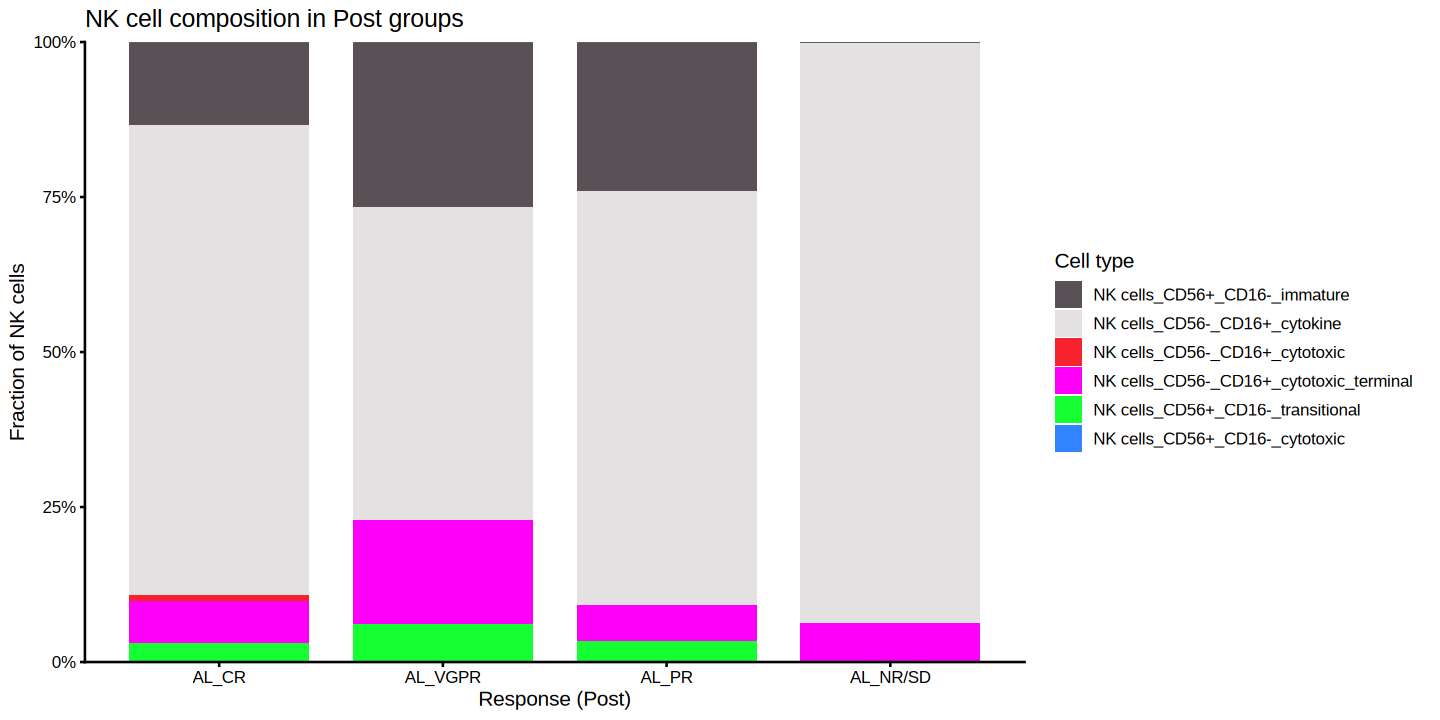

In [19]:
# --- Stacked bar plot for Pre groups ---
options(repr.plot.height = 6, repr.plot.width = 12)

comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","Normal", "AL_NotRecorded"))

p_pre <- ggplot(
  comp %>%
    filter(treatment == "Pre",
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Pre)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition in Pre groups") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_pre)

# --- Stacked bar plot for Post groups ---
p_post <- ggplot(
  comp %>%
    filter(treatment == "Post",
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Post)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition in Post groups") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_post)


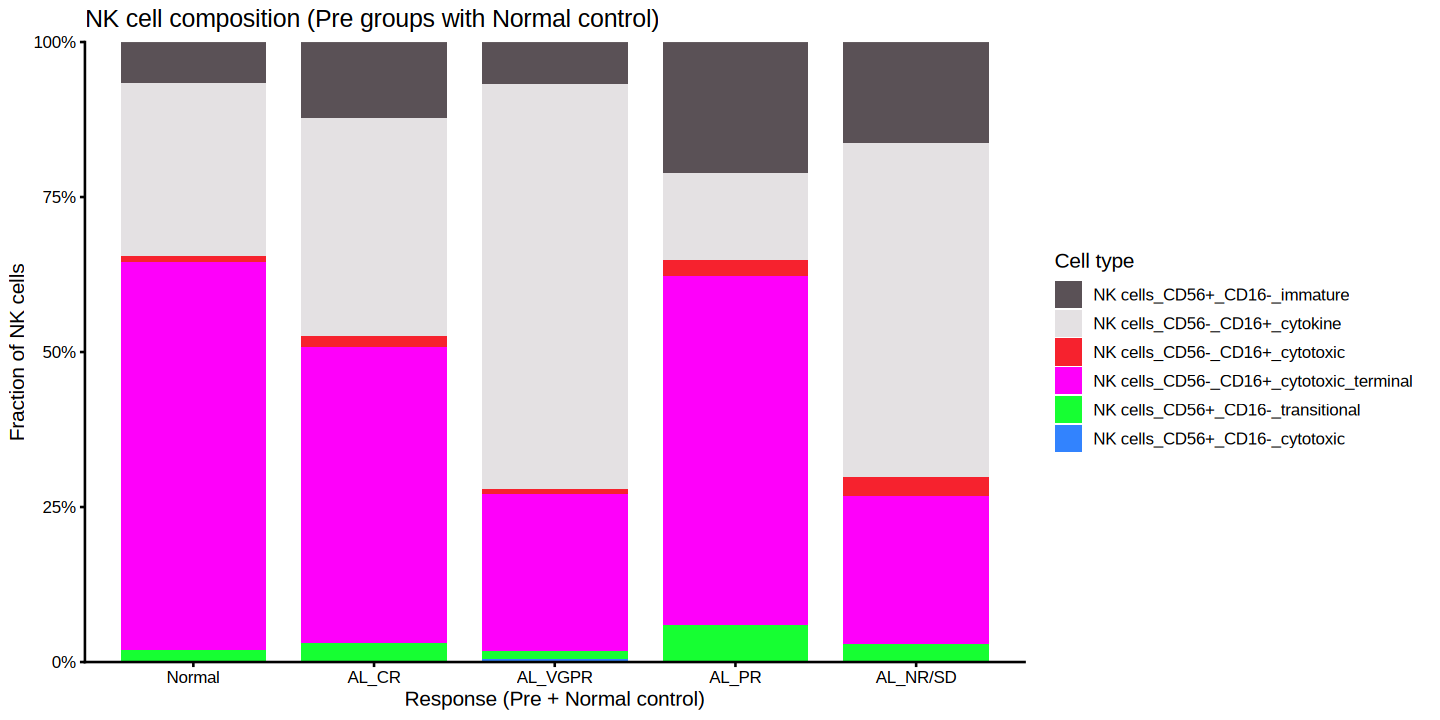

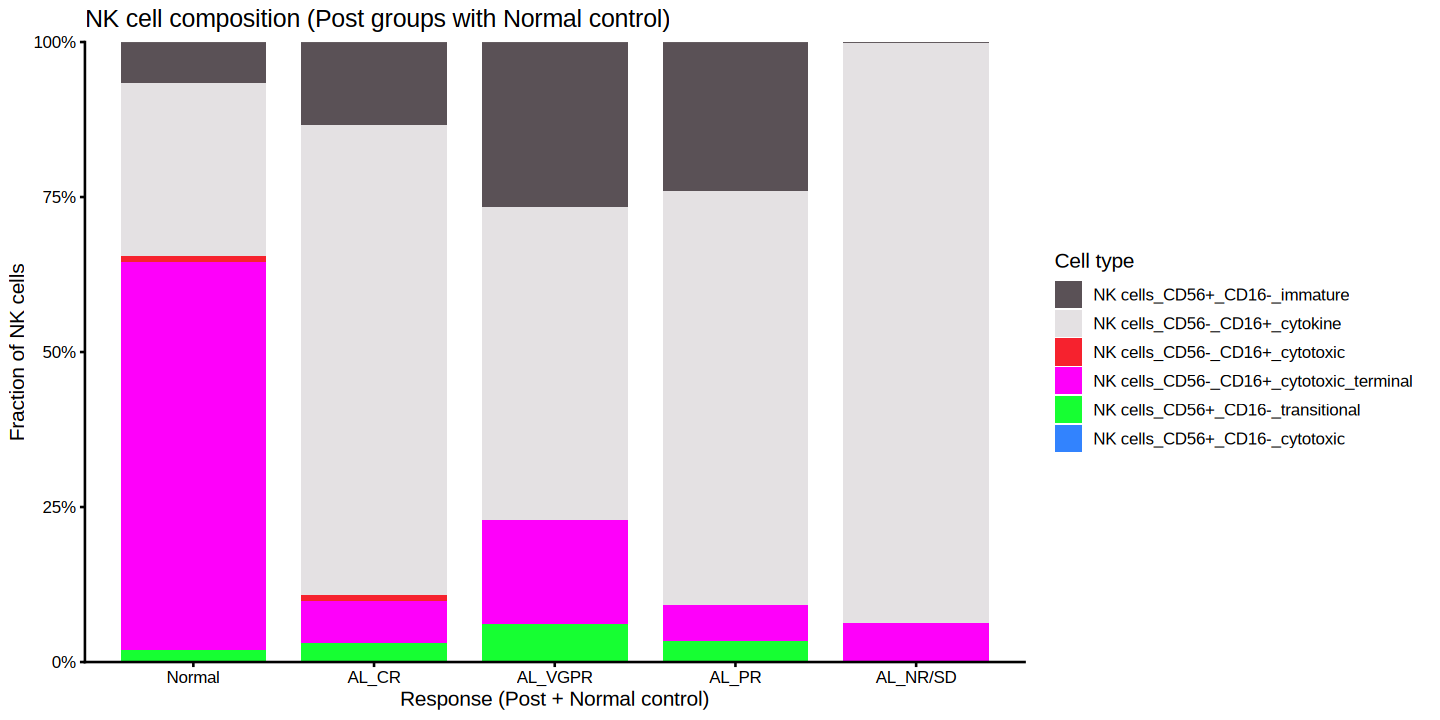

In [20]:
library(dplyr)
library(ggplot2)
library(scales)

# --- Ensure consistent response order ---
comp$response <- factor(
  comp$response,
  levels = c("Normal", "AL_NotRecorded", "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")
)

# --- 1) Collapse Normal group (no treatment) ---
normal_bar <- comp %>%
  filter(response == "Normal") %>%
  group_by(celltype) %>%
  summarise(frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  mutate(response = "Normal") %>%
  # Ensure Normal sums to 1 across celltypes
  mutate(frac = frac / sum(frac, na.rm = TRUE))

# --- 2) Pre dataset: keep only Pre rows + Normal bar ---
comp_pre_dat <- comp %>%
  filter(treatment == "Pre",
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  select(response, celltype, frac)

comp_pre_dat <- bind_rows(
  normal_bar,    # Normal has no treatment
  comp_pre_dat
) %>%
  # Normalize within each response so each stacked bar = 100%
  group_by(response) %>%
  mutate(frac = frac / sum(frac, na.rm = TRUE)) %>%
  ungroup()

# --- 3) Post dataset: keep only Post rows + Normal bar ---
comp_post_dat <- comp %>%
  filter(treatment == "Post",
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  select(response, celltype, frac)

comp_post_dat <- bind_rows(
  normal_bar,    # Normal has no treatment
  comp_post_dat
) %>%
  # Normalize within each response so each stacked bar = 100%
  group_by(response) %>%
  mutate(frac = frac / sum(frac, na.rm = TRUE)) %>%
  ungroup()

# (Keep your plotting code unchanged)


# --- 4) Fix factor levels again ---
comp_pre_dat$response  <- factor(comp_pre_dat$response,  levels = levels(comp$response))
comp_post_dat$response <- factor(comp_post_dat$response, levels = levels(comp$response))

# --- 5) Stacked bar plot for Pre groups + Normal ---
options(repr.plot.height = 6, repr.plot.width = 12)

p_pre <- ggplot(
  comp_pre_dat,
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Pre + Normal control)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition (Pre groups with Normal control)") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_pre)

# --- 6) Stacked bar plot for Post groups + Normal ---
p_post <- ggplot(
  comp_post_dat,
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Post + Normal control)", y = "Fraction of NK cells", fill = "Cell type",
       title = "NK cell composition (Post groups with Normal control)") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_post)


In [21]:
sce1_nkcell@meta.data$barcode<-rownames(sce1_nkcell@meta.data)
label<-sce1_nkcell@meta.data[,c('barcode','Annotation')]
write.csv(label,file='NKcell.noverlabel.csv')

## 6. Sample metadata and clinical groups


In [22]:
# 0) Clean labels and derive response/treatment per cell (anchored)
sce1_nkcell$label <- as.character(sce1_nkcell$label)
sce1_nkcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_nkcell$label)

meta_df <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label),
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),
    celltype  = Annotation
  )


# Attach for convenience
sce1_nkcell$response  <- meta_df$response
sce1_nkcell$treatment <- meta_df$treatment


In [23]:
# 1) Keep only valid Pre/Post cells for expression averaging
valid <- with(meta_df, !is.na(response) & !is.na(treatment))
sce_expr <- subset(sce1_nkcell, cells = rownames(meta_df)[valid])

# 2) Define markers (gene symbols in RNA assay)
marker_map <- c(TIGIT='TIGIT',HAVCR2='HAVCR2',CD96='CD96',KLRG1='KLRG1',LAG3='LAG3', PDCD1  = "PDCD1")
features_to_use <- unique(unname(marker_map))

# 3) Build grouping key for averaging: response|treatment|celltype
sce_expr$resp_treat_ct <- with(sce_expr@meta.data, paste(response, treatment, Annotation, sep = "|"))



In [24]:
avg <- AverageExpression(
  sce_expr,
  features = features_to_use,
  group.by = "resp_treat_ct",
  assays = "RNA",
  slot = "data"
)$RNA
# rows = genes, cols = "response|treatment|celltype"


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


## 7. Sample metadata and clinical groups


In [25]:
# 4) Tidy to long + map gene -> marker
df_expr <- as.data.frame(avg) %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "grp", values_to = "expr") %>%
  separate(grp, into = c("response","treatment","celltype"), sep = "\\|", fill = "right") %>%
  filter(!is.na(response), !is.na(treatment), !is.na(celltype)) %>%
  mutate(marker = names(marker_map)[match(gene, marker_map[marker_map %in% gene])]) %>%
  filter(!is.na(marker))

In [26]:
# 5) Prepare diverging values (Pre negative, Post positive) + response grouping
df_plot <- df_expr %>%
  mutate(
    response  = factor(response, levels = c("AL-CR","AL-VGPR","AL-PR","AL-NR/SD")),
    treatment = factor(treatment, levels = c("Pre","Post")),
    celltype  = celltype,
    value     = ifelse(treatment == "Post", expr, -expr),
    response_group = case_when(
      response %in% c("AL-CR","AL-VGPR")   ~ "Good",
      response %in% c("AL-PR","AL-NR/SD")  ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  # Omit anything not mapped (e.g., Normal / AL_NotRecorded) only in the plot
  filter(!is.na(response_group)) %>%
  mutate(response_group = factor(response_group, levels = c("Good","Poor")))

# Labels for the grouped facet
grp_labeller <- as_labeller(c(Good = "Good (CR + VGPR)", Poor = "Poor (PR + NR/SD)"))

options(repr.plot.height = 10, repr.plot.width = 8)



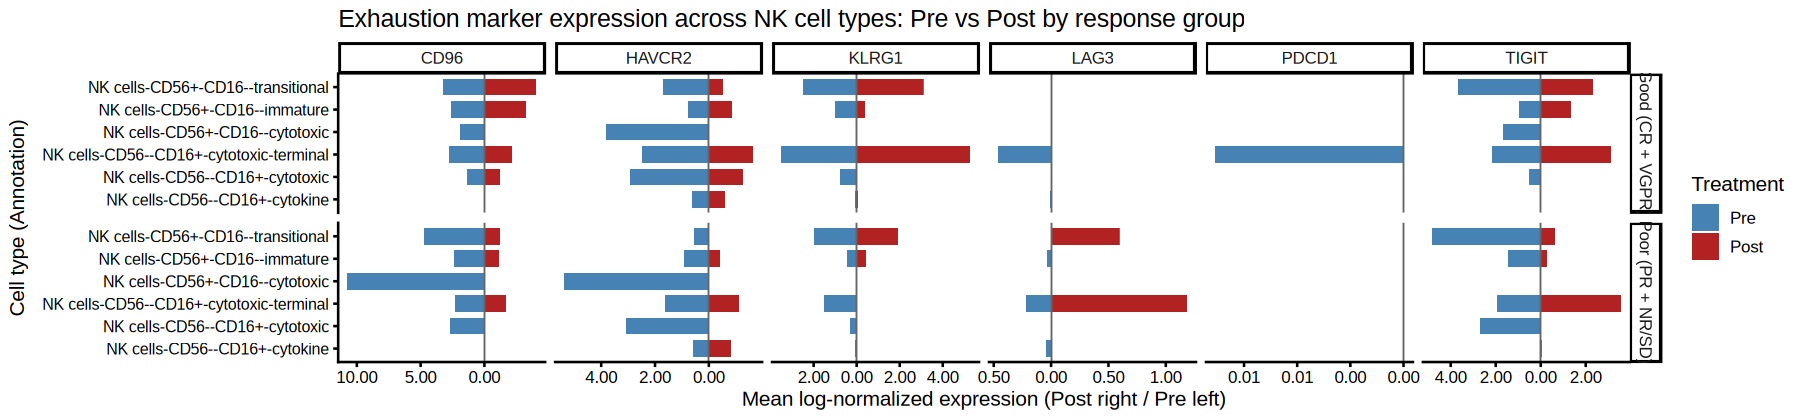

In [27]:
# Group responses (CR/VGPR -> Good; PR/NR/SD -> Poor)
df_plot <- df_expr %>%
  mutate(
    response  = factor(response, levels = c("AL-CR","AL-VGPR","AL-PR","AL-NR/SD")),
    treatment = factor(treatment, levels = c("Pre","Post")),
    value     = ifelse(treatment == "Post", expr, -expr),
    response_group = case_when(
      response %in% c("AL-CR","AL-VGPR")  ~ "Good",
      response %in% c("AL-PR","AL-NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(response_group)) %>%
  mutate(response_group = factor(response_group, levels = c("Good","Poor")))

grp_labeller <- as_labeller(c(Good = "Good (CR + VGPR)", Poor = "Poor (PR + NR/SD)"))

options(repr.plot.height = 3.5, repr.plot.width = 15)

p_diverge <- ggplot(df_plot, aes(x = celltype, y = value, fill = treatment)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0, linewidth = 0.4, color = "grey40") +
  coord_flip() +
  facet_grid(
    rows = vars(response_group),  # <-- Good/Poor as rows
    cols = vars(marker),          # <-- markers as columns
    labeller = labeller(response_group = grp_labeller),
    scales = "free_x"
  ) +
  scale_y_continuous(labels = function(x) sprintf("%.2f", abs(x))) +
  scale_fill_manual(values = c("Pre" = "steelblue", "Post" = "firebrick")) +
  labs(
    x = "Cell type (Annotation)",
    y = "Mean log-normalized expression (Post right / Pre left)",
    fill = "Treatment",
    title = "Exhaustion marker expression across NK cell types: Pre vs Post by response group"
  ) +
  theme_classic(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 9),
    legend.position = "right"
  )

print(p_diverge)


In [28]:
ggsave("Fig6i.pdf", plot = p_diverge, width = 15, height =3.5)


In [38]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(ggpubr)
  library(RColorBrewer)
  library(broom)
  library(scales)
  library(effsize)
  library(stringr)
})

# =========================================================
# 0) SETTINGS
# =========================================================
sample_col <- "orig.ident"
celltype_col <- "Annotation"
assay_use <- "RNA"

marker_pos_cutoff <- 0
min_cells_per_sample_group <- 5

marker_map <- c(
  CD96   = "CD96",
  LAG3  = "LAG3",
  TIGIT  = "TIGIT",
  KLRG1  = "KLRG1"
)

response_levels <- c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")

outdir_pdf <- "isolated_boxplots_by_celltype_good_poor"
dir.create(outdir_pdf, showWarnings = FALSE, recursive = TRUE)

# =========================================================
# 1) REQUIRED META CHECK
# =========================================================
required_meta <- c("label", sample_col, celltype_col)

missing_meta <- setdiff(required_meta, colnames(sce1_nkcell@meta.data))

if (length(missing_meta) > 0) {
  stop("Missing metadata columns: ", paste(missing_meta, collapse = ", "))
}

# =========================================================
# 2) CLEAN LABELS / DERIVE RESPONSE, TREATMENT, RESPONSE GROUP
# =========================================================
sce1_nkcell$label <- as.character(sce1_nkcell$label)
sce1_nkcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_nkcell$label)

meta_df <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  rownames_to_column("cell_id") %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", as.character(label)),

    response = sub(
      pattern = "_(pre|post)$",
      replacement = "",
      x = label_clean,
      ignore.case = TRUE,
      perl = TRUE
    ),

    treatment = case_when(
      grepl("_pre$", label_clean, ignore.case = TRUE, perl = TRUE)  ~ "Pre",
      grepl("_post$", label_clean, ignore.case = TRUE, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),

    response_group = case_when(
      response %in% c("AL_CR", "AL_VGPR")  ~ "Good",
      response %in% c("AL_PR", "AL_NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),

    sample_id = as.character(.data[[sample_col]]),
    celltype  = as.character(.data[[celltype_col]])
  ) %>%
  mutate(
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

valid_cells <- meta_df %>%
  filter(
    !is.na(response),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(sample_id),
    !is.na(celltype)
  ) %>%
  pull(cell_id)

if (length(valid_cells) == 0) {
  stop(
    "No valid cells remained after parsing label into response/treatment/response_group.\n",
    "Check that sce1_nkcell$label looks like AL_CR_pre, AL_VGPR_post, AL_PR_pre, or AL_NR/SD_post.\n",
    "Example labels found: ",
    paste(head(unique(meta_df$label_clean), 10), collapse = ", ")
  )
}

sce_expr <- subset(sce1_nkcell, cells = valid_cells)

meta_join <- meta_df %>%
  filter(cell_id %in% valid_cells) %>%
  select(
    cell_id,
    label_clean,
    response,
    treatment,
    response_group,
    sample_id,
    celltype
  )

message("Valid cells retained: ", length(valid_cells), " / ", ncol(sce1_nkcell))

# =========================================================
# 3) CHECK MARKER GENES
# =========================================================
features_to_use <- unique(unname(marker_map))
genes_present <- intersect(features_to_use, rownames(sce_expr[[assay_use]]))

if (length(genes_present) == 0) {
  stop("None of the exhaustion marker genes were found in the ", assay_use, " assay.")
}

missing_genes <- setdiff(features_to_use, genes_present)

if (length(missing_genes) > 0) {
  warning(
    "These genes were not found and will be skipped: ",
    paste(missing_genes, collapse = ", ")
  )
}

marker_map_use <- marker_map[unname(marker_map) %in% genes_present]

message("Genes used: ", paste(genes_present, collapse = ", "))

# =========================================================
# 4) FETCH EXPRESSION ONLY
# =========================================================
fetch_expr_only <- function(obj, vars, assay_use) {
  tryCatch(
    {
      FetchData(
        obj,
        vars = vars,
        assay = assay_use,
        layer = "data"
      )
    },
    error = function(e_layer) {
      tryCatch(
        {
          FetchData(
            obj,
            vars = vars,
            assay = assay_use,
            slot = "data"
          )
        },
        error = function(e_slot) {
          stop(
            "FetchData failed with both layer='data' and slot='data'.\n",
            "Layer error: ", conditionMessage(e_layer), "\n",
            "Slot error: ", conditionMessage(e_slot)
          )
        }
      )
    }
  )
}

expr_df <- fetch_expr_only(
  obj = sce_expr,
  vars = genes_present,
  assay_use = assay_use
) %>%
  rownames_to_column("cell_id") %>%
  left_join(meta_join, by = "cell_id") %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype = as.character(celltype),
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (any(is.na(expr_df$response_group))) {
  warning(
    "Some cells have NA response_group after joining metadata. These will be removed."
  )
}

# =========================================================
# 5) LONG FORMAT
# =========================================================
df_long <- expr_df %>%
  pivot_longer(
    cols = all_of(genes_present),
    names_to = "gene",
    values_to = "expr"
  ) %>%
  mutate(
    marker = names(marker_map_use)[match(gene, unname(marker_map_use))],
    marker_positive = expr > marker_pos_cutoff
  ) %>%
  filter(
    !is.na(marker),
    is.finite(expr),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(celltype),
    !is.na(sample_id)
  ) %>%
  mutate(
    marker = factor(marker, levels = names(marker_map_use)),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (nrow(df_long) == 0) {
  stop("No rows remained in df_long after expression and metadata filtering.")
}

# =========================================================
# 6) BUILD ANALYSIS GROUPS
#    - each cell type individually
#    - pooled CD4*: all CD4-like cells + Treg
#    - pooled CD8*: all CD8-like cells + MAIT
# =========================================================
df_long <- df_long %>%
  mutate(
    is_cd4 = str_detect(celltype, regex("CD4", ignore_case = TRUE)) |
      str_detect(celltype, regex("Treg|T_reg|Regulatory", ignore_case = TRUE)),

    is_cd8 = str_detect(celltype, regex("CD8", ignore_case = TRUE)) |
      str_detect(celltype, regex("MAIT", ignore_case = TRUE))
  )

# individual cell types
df_individual <- df_long %>%
  mutate(plot_group = celltype)

# pooled CD4*: CD4 + Treg
df_cd4 <- df_long %>%
  filter(is_cd4) %>%
  mutate(plot_group = "All CD4*")

# pooled CD8*: CD8 + MAIT
df_cd8 <- df_long %>%
  filter(is_cd8) %>%
  mutate(plot_group = "All CD8*")

df_plot_input <- bind_rows(df_individual, df_cd4, df_cd8)

plot_group_levels <- c(
  sort(unique(as.character(df_individual$plot_group))),
  "All CD4*",
  "All CD8*"
)

df_plot_input <- df_plot_input %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

# =========================================================
# 7) SAMPLE-LEVEL % POSITIVE
# =========================================================
df_sample <- df_plot_input %>%
  group_by(
    sample_id,
    plot_group,
    response_group,
    treatment,
    marker
  ) %>%
  summarise(
    pct_positive = 100 * mean(marker_positive, na.rm = TRUE),
    n_cells = n(),
    .groups = "drop"
  ) %>%
  filter(n_cells >= min_cells_per_sample_group) %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor")),
    marker = factor(marker, levels = names(marker_map_use))
  )

if (nrow(df_sample) == 0) {
  stop(
    "No sample-level rows remained after min_cells_per_sample_group filtering. ",
    "Try lowering min_cells_per_sample_group."
  )
}

# =========================================================
# 8) PER-SUBPANEL STATS
#    within each plot_group x marker x treatment:
#    compare Good vs Poor
# =========================================================
row_max <- df_sample %>%
  group_by(plot_group, marker, treatment) %>%
  summarise(
    ymax = max(pct_positive, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    ypos = ifelse(is.finite(ymax), ymax * 1.05 + 1, 5)
  )

wilcox_df <- df_sample %>%
  group_by(plot_group, marker, treatment) %>%
  summarise(
    p = tryCatch({
      has_good <- any(response_group == "Good" & !is.na(pct_positive))
      has_poor <- any(response_group == "Poor" & !is.na(pct_positive))

      if (has_good && has_poor) {
        broom::glance(
          wilcox.test(pct_positive ~ response_group, exact = FALSE)
        )$p.value
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

cliff_df <- df_sample %>%
  group_by(plot_group, marker, treatment) %>%
  summarise(
    cliffs_delta = tryCatch({
      good <- pct_positive[response_group == "Good"]
      poor <- pct_positive[response_group == "Poor"]

      if (sum(!is.na(good)) > 0 && sum(!is.na(poor)) > 0) {
        unname(effsize::cliff.delta(poor, good, na.rm = TRUE)$estimate)
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

annot_df <- wilcox_df %>%
  left_join(row_max, by = c("plot_group", "marker", "treatment")) %>%
  left_join(cliff_df, by = c("plot_group", "marker", "treatment")) %>%
  mutate(
    annotation_x = factor("Poor", levels = c("Good", "Poor")),
    label = paste0(
      "Wilcoxon p = ",
      ifelse(is.na(p), "NA", scales::pvalue(p)),
      "\nCliff\u0394 (Poor vs Good) = ",
      ifelse(
        is.na(cliffs_delta),
        "NA",
        scales::number(cliffs_delta, accuracy = 0.01)
      )
    )
  )

# =========================================================
# 9) SAFE FILE NAME
# =========================================================
safe_filename <- function(x) {
  x <- as.character(x)
  x <- gsub("[/\\s\\+\\*]+", "_", x)
  x <- gsub("[^A-Za-z0-9_\\-]", "", x)
  x
}

# =========================================================
# 10) PLOT FUNCTION
#     one isolated plot per cell type / pooled group
#     swapped facets:
#     rows = treatment
#     cols = marker
# =========================================================
make_one_plot <- function(one_group, df_sample, annot_df, marker_pos_cutoff = 0) {

  df_sub <- df_sample %>%
    filter(plot_group == one_group)

  annot_sub <- annot_df %>%
    filter(plot_group == one_group)

  if (nrow(df_sub) == 0) {
    return(NULL)
  }

  p <- ggboxplot(
    df_sub,
    x = "response_group",
    y = "pct_positive",
    fill = "response_group",
    width = 0.6,
    outlier.shape = NA
  ) +
    geom_jitter(
      aes(
        x = response_group,
        y = pct_positive
      ),
      width = 0.12,
      height = 0,
      size = 1.6,
      alpha = 0.75,
      inherit.aes = FALSE
    ) +
    scale_fill_brewer(
      palette = "Set1",
      drop = FALSE
    ) +
    facet_grid(
      treatment ~ marker,
      scales = "free_y",
      switch = "y"
    ) +
    labs(
      x = "Response group",
      y = "% marker-positive cells per sample",
      title = as.character(one_group),
      subtitle = paste0(
        "Good vs Poor within Pre/Post timepoints",
        "  |  positive cutoff: expression > ",
        marker_pos_cutoff
      )
    ) +
    theme_classic(base_size = 12) +
    theme(
      axis.text.x = element_text(
        angle = 0,
        hjust = 0.5,
        face = "bold"
      ),
      legend.position = "none",
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        colour = NA
      ),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold"
      ),
      strip.text.x = element_text(face = "bold"),
      plot.margin = margin(5.5, 50, 5.5, 5.5),
      panel.spacing = unit(6, "pt"),
      plot.title = element_text(face = "bold")
    ) +
    scale_y_continuous(
      expand = expansion(mult = c(0.05, 0.30))
    ) +
    coord_cartesian(clip = "off") +
    geom_text(
      data = annot_sub,
      aes(
        x = annotation_x,
        y = ypos,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1.02,
      vjust = 0.5,
      lineheight = 1.05,
      size = 3.2
    )

  p
}

# =========================================================
# 11) GENERATE ALL PLOTS
# =========================================================
plot_groups_to_make <- intersect(
  plot_group_levels,
  unique(as.character(df_sample$plot_group))
)

plot_list <- lapply(plot_groups_to_make, function(g) {
  make_one_plot(
    one_group = g,
    df_sample = df_sample,
    annot_df = annot_df,
    marker_pos_cutoff = marker_pos_cutoff
  )
})

names(plot_list) <- plot_groups_to_make

# =========================================================
# 12) SAVE EACH AS INDEPENDENT PDF
# =========================================================
saved_files_df <- tibble(
  plot_group = character(),
  pdf_file = character()
)

for (nm in names(plot_list)) {

  p <- plot_list[[nm]]

  if (is.null(p)) {
    next
  }

  file_out <- file.path(
    outdir_pdf,
    paste0("boxplot_", safe_filename(nm), ".pdf")
  )

  n_markers <- df_sample %>%
    filter(plot_group == nm) %>%
    distinct(marker) %>%
    nrow()

  plot_height <- max(4.8, 2.8 + 1.2 * 2)

  ggsave(
    filename = file_out,
    plot = p,
    width = max(6.6, 1.6 * n_markers + 2.5),
    height = plot_height,
    units = "in"
  )

  saved_files_df <- bind_rows(
    saved_files_df,
    tibble(
      plot_group = nm,
      pdf_file = file_out
    )
  )
}

# =========================================================
# 13) SAVE OPTIONAL MULTI-PAGE PDF
# =========================================================
multi_pdf <- file.path(
  outdir_pdf,
  "ALL_boxplots_by_celltype_good_poor.pdf"
)

pdf(
  file = multi_pdf,
  width = 10,
  height = 5.5,
  onefile = TRUE
)

for (nm in names(plot_list)) {
  p <- plot_list[[nm]]
  if (!is.null(p)) {
    print(p)
  }
}

dev.off()

# =========================================================
# 14) SAVE FILE MANIFEST
# =========================================================
write.csv(
  saved_files_df,
  file.path(outdir_pdf, "saved_plot_files.csv"),
  row.names = FALSE
)

saved_files_df

Valid cells retained: 3756 / 4245

Genes used: CD96, LAG3, TIGIT, KLRG1

Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `cliffs_delta = tryCatch(...)`.
ℹ In group 12: `plot_group = NK cells_CD56-_CD16+_cytotoxic`, `marker = KLRG1`,
  `treatment = Pre`.
Caused by warning in `cliff.delta.default()`:
! The samples are fully disjoint, using approximate Confidence Interval estimation
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.08' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.08' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.

pdf 
  2

plot_group,pdf_file
<chr>,<chr>
NK cells_CD56-_CD16+_cytokine,isolated_boxplots_by_celltype_good_poor/boxplot_NKcell__CD56-_CD16__cytokine.pdf
NK cells_CD56-_CD16+_cytotoxic,isolated_boxplots_by_celltype_good_poor/boxplot_NKcell__CD56-_CD16__cytotoxic.pdf
NK cells_CD56-_CD16+_cytotoxic_terminal,isolated_boxplots_by_celltype_good_poor/boxplot_NKcell__CD56-_CD16__cytotoxic_terminal.pdf
NK cells_CD56+_CD16-_immature,isolated_boxplots_by_celltype_good_poor/boxplot_NKcell__CD56__CD16-_immature.pdf
NK cells_CD56+_CD16-_transitional,isolated_boxplots_by_celltype_good_poor/boxplot_NKcell__CD56__CD16-_tran_itional.pdf


## 8. Sample metadata and clinical groups


In [39]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(ggpubr)
  library(RColorBrewer)
  library(broom)
  library(scales)
  library(effsize)
  library(stringr)
})

# =========================================================
# 0) SETTINGS
# =========================================================
sample_col <- "orig.ident"
celltype_col <- "Annotation"
assay_use <- "RNA"

marker_pos_cutoff <- 0
min_cells_per_sample_group <- 5


marker_map <- c(
  CD96   = "CD96",
  LAG3  = "LAG3",
  TIGIT  = "TIGIT",
  KLRG1  = "KLRG1"
)

response_levels <- c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")

outdir_pdf <- "isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows"
dir.create(outdir_pdf, showWarnings = FALSE, recursive = TRUE)

# =========================================================
# 1) REQUIRED META CHECK
# =========================================================
required_meta <- c("label", sample_col, celltype_col)

missing_meta <- setdiff(required_meta, colnames(sce1_nkcell@meta.data))

if (length(missing_meta) > 0) {
  stop("Missing metadata columns: ", paste(missing_meta, collapse = ", "))
}

# =========================================================
# 2) CLEAN LABELS / DERIVE RESPONSE, TREATMENT, RESPONSE GROUP
# =========================================================
sce1_nkcell$label <- as.character(sce1_nkcell$label)
sce1_nkcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_nkcell$label)

meta_df <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  rownames_to_column("cell_id") %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", as.character(label)),

    response = sub(
      pattern = "_(pre|post)$",
      replacement = "",
      x = label_clean,
      ignore.case = TRUE,
      perl = TRUE
    ),

    treatment = case_when(
      grepl("_pre$", label_clean, ignore.case = TRUE, perl = TRUE)  ~ "Pre",
      grepl("_post$", label_clean, ignore.case = TRUE, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),

    response_group = case_when(
      response %in% c("AL_CR", "AL_VGPR")  ~ "Good",
      response %in% c("AL_PR", "AL_NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),

    sample_id = as.character(.data[[sample_col]]),
    celltype  = as.character(.data[[celltype_col]])
  ) %>%
  mutate(
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

valid_cells <- meta_df %>%
  filter(
    !is.na(response),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(sample_id),
    !is.na(celltype)
  ) %>%
  pull(cell_id)

if (length(valid_cells) == 0) {
  stop(
    "No valid cells remained after parsing label into response/treatment/response_group.\n",
    "Check that sce1_nkcell$label looks like AL_CR_pre, AL_VGPR_post, AL_PR_pre, or AL_NR/SD_post.\n",
    "Example labels found: ",
    paste(head(unique(meta_df$label_clean), 10), collapse = ", ")
  )
}

sce_expr <- subset(sce1_nkcell, cells = valid_cells)

meta_join <- meta_df %>%
  filter(cell_id %in% valid_cells) %>%
  select(
    cell_id,
    label_clean,
    response,
    treatment,
    response_group,
    sample_id,
    celltype
  )

message("Valid cells retained: ", length(valid_cells), " / ", ncol(sce1_nkcell))

# =========================================================
# 3) CHECK MARKER GENES
# =========================================================
features_to_use <- unique(unname(marker_map))
genes_present <- intersect(features_to_use, rownames(sce_expr[[assay_use]]))

if (length(genes_present) == 0) {
  stop("None of the exhaustion marker genes were found in the ", assay_use, " assay.")
}

missing_genes <- setdiff(features_to_use, genes_present)

if (length(missing_genes) > 0) {
  warning(
    "These genes were not found and will be skipped: ",
    paste(missing_genes, collapse = ", ")
  )
}

marker_map_use <- marker_map[unname(marker_map) %in% genes_present]

message("Genes used: ", paste(genes_present, collapse = ", "))

# =========================================================
# 4) FETCH EXPRESSION ONLY
# =========================================================
fetch_expr_only <- function(obj, vars, assay_use) {
  tryCatch(
    {
      FetchData(
        obj,
        vars = vars,
        assay = assay_use,
        layer = "data"
      )
    },
    error = function(e_layer) {
      tryCatch(
        {
          FetchData(
            obj,
            vars = vars,
            assay = assay_use,
            slot = "data"
          )
        },
        error = function(e_slot) {
          stop(
            "FetchData failed with both layer='data' and slot='data'.\n",
            "Layer error: ", conditionMessage(e_layer), "\n",
            "Slot error: ", conditionMessage(e_slot)
          )
        }
      )
    }
  )
}

expr_df <- fetch_expr_only(
  obj = sce_expr,
  vars = genes_present,
  assay_use = assay_use
) %>%
  rownames_to_column("cell_id") %>%
  left_join(meta_join, by = "cell_id") %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype = as.character(celltype),
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (any(is.na(expr_df$response_group))) {
  warning(
    "Some cells have NA response_group after joining metadata. These will be removed."
  )
}

# =========================================================
# 5) LONG FORMAT
# =========================================================
df_long <- expr_df %>%
  pivot_longer(
    cols = all_of(genes_present),
    names_to = "gene",
    values_to = "expr"
  ) %>%
  mutate(
    marker = names(marker_map_use)[match(gene, unname(marker_map_use))],
    marker_positive = expr > marker_pos_cutoff
  ) %>%
  filter(
    !is.na(marker),
    is.finite(expr),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(celltype),
    !is.na(sample_id)
  ) %>%
  mutate(
    marker = factor(marker, levels = names(marker_map_use)),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (nrow(df_long) == 0) {
  stop("No rows remained in df_long after expression and metadata filtering.")
}

# =========================================================
# 6) BUILD ANALYSIS GROUPS
#    - each cell type individually
#    - pooled CD4*: all CD4-like cells + Treg
#    - pooled CD8*: all CD8-like cells + MAIT
# =========================================================
df_long <- df_long %>%
  mutate(
    is_cd4 = str_detect(celltype, regex("CD4", ignore_case = TRUE)) |
      str_detect(celltype, regex("Treg|T_reg|Regulatory", ignore_case = TRUE)),

    is_cd8 = str_detect(celltype, regex("CD8", ignore_case = TRUE)) |
      str_detect(celltype, regex("MAIT", ignore_case = TRUE))
  )

# individual cell types
df_individual <- df_long %>%
  mutate(plot_group = celltype)

# pooled CD4*: CD4 + Treg
df_cd4 <- df_long %>%
  filter(is_cd4) %>%
  mutate(plot_group = "All CD4*")

# pooled CD8*: CD8 + MAIT
df_cd8 <- df_long %>%
  filter(is_cd8) %>%
  mutate(plot_group = "All CD8*")

df_plot_input <- bind_rows(df_individual, df_cd4, df_cd8)

plot_group_levels <- c(
  sort(unique(as.character(df_individual$plot_group))),
  "All CD4*",
  "All CD8*"
)

df_plot_input <- df_plot_input %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

# =========================================================
# 7) SAMPLE-LEVEL % POSITIVE
# =========================================================
df_sample <- df_plot_input %>%
  group_by(
    sample_id,
    plot_group,
    response_group,
    treatment,
    marker
  ) %>%
  summarise(
    pct_positive = 100 * mean(marker_positive, na.rm = TRUE),
    n_cells = n(),
    .groups = "drop"
  ) %>%
  filter(n_cells >= min_cells_per_sample_group) %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor")),
    marker = factor(marker, levels = names(marker_map_use))
  )

if (nrow(df_sample) == 0) {
  stop(
    "No sample-level rows remained after min_cells_per_sample_group filtering. ",
    "Try lowering min_cells_per_sample_group."
  )
}

# =========================================================
# 8) PER-SUBPANEL STATS
#    within each plot_group x marker x response_group:
#    compare Pre vs Post
# =========================================================
row_max <- df_sample %>%
  group_by(plot_group, marker, response_group) %>%
  summarise(
    ymax = max(pct_positive, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    ypos = ifelse(is.finite(ymax), ymax * 1.05 + 1, 5)
  )

wilcox_df <- df_sample %>%
  group_by(plot_group, marker, response_group) %>%
  summarise(
    p = tryCatch({
      has_pre  <- any(treatment == "Pre"  & !is.na(pct_positive))
      has_post <- any(treatment == "Post" & !is.na(pct_positive))

      if (has_pre && has_post) {
        broom::glance(
          wilcox.test(pct_positive ~ treatment, exact = FALSE)
        )$p.value
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

cliff_df <- df_sample %>%
  group_by(plot_group, marker, response_group) %>%
  summarise(
    cliffs_delta = tryCatch({
      pre  <- pct_positive[treatment == "Pre"]
      post <- pct_positive[treatment == "Post"]

      if (sum(!is.na(pre)) > 0 && sum(!is.na(post)) > 0) {
        unname(effsize::cliff.delta(post, pre, na.rm = TRUE)$estimate)
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

annot_df <- wilcox_df %>%
  left_join(row_max, by = c("plot_group", "marker", "response_group")) %>%
  left_join(cliff_df, by = c("plot_group", "marker", "response_group")) %>%
  mutate(
    annotation_x = factor("Post", levels = c("Pre", "Post")),
    label = paste0(
      "Wilcoxon p = ",
      ifelse(is.na(p), "NA", scales::pvalue(p)),
      "\nCliff\u0394 (Post vs Pre) = ",
      ifelse(
        is.na(cliffs_delta),
        "NA",
        scales::number(cliffs_delta, accuracy = 0.01)
      )
    )
  )

# =========================================================
# 9) SAFE FILE NAME
# =========================================================
safe_filename <- function(x) {
  x <- as.character(x)
  x <- gsub("[/\\s\\+\\*]+", "_", x)
  x <- gsub("[^A-Za-z0-9_\\-]", "", x)
  x
}

# =========================================================
# 10) PLOT FUNCTION
#     one isolated plot per cell type / pooled group
#
#     Desired layout:
#       columns = genes / markers
#       rows    = Good / Poor response groups
#       x-axis  = Pre / Post
# =========================================================
make_one_plot <- function(one_group, df_sample, annot_df, marker_pos_cutoff = 0) {

  df_sub <- df_sample %>%
    filter(plot_group == one_group)

  annot_sub <- annot_df %>%
    filter(plot_group == one_group)

  if (nrow(df_sub) == 0) {
    return(NULL)
  }

  p <- ggboxplot(
    df_sub,
    x = "treatment",
    y = "pct_positive",
    fill = "treatment",
    width = 0.6,
    outlier.shape = NA
  ) +
    geom_jitter(
      aes(
        x = treatment,
        y = pct_positive
      ),
      width = 0.12,
      height = 0,
      size = 1.6,
      alpha = 0.75,
      inherit.aes = FALSE
    ) +
    scale_fill_brewer(
      palette = "Set1",
      drop = FALSE
    ) +
    facet_grid(
      response_group ~ marker,
      scales = "free_y",
      switch = "y"
    ) +
    labs(
      x = "Timepoint",
      y = "% marker-positive cells per sample",
      title = as.character(one_group),
      subtitle = paste0(
        "Pre vs Post within Good/Poor groups",
        "  |  positive cutoff: expression > ",
        marker_pos_cutoff
      )
    ) +
    theme_classic(base_size = 12) +
    theme(
      axis.text.x = element_text(
        angle = 0,
        hjust = 0.5,
        face = "bold"
      ),
      legend.position = "none",
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        colour = NA
      ),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold"
      ),
      strip.text.x = element_text(face = "bold"),
      plot.margin = margin(5.5, 50, 5.5, 5.5),
      panel.spacing = unit(6, "pt"),
      plot.title = element_text(face = "bold")
    ) +
    scale_y_continuous(
      expand = expansion(mult = c(0.05, 0.30))
    ) +
    coord_cartesian(clip = "off") +
    geom_text(
      data = annot_sub,
      aes(
        x = annotation_x,
        y = ypos,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1.02,
      vjust = 0.5,
      lineheight = 1.05,
      size = 3.0
    )

  p
}

# =========================================================
# 11) GENERATE ALL PLOTS
# =========================================================
plot_groups_to_make <- intersect(
  plot_group_levels,
  unique(as.character(df_sample$plot_group))
)

plot_list <- lapply(plot_groups_to_make, function(g) {
  make_one_plot(
    one_group = g,
    df_sample = df_sample,
    annot_df = annot_df,
    marker_pos_cutoff = marker_pos_cutoff
  )
})

names(plot_list) <- plot_groups_to_make

# =========================================================
# 12) SAVE EACH AS INDEPENDENT PDF
# =========================================================
saved_files_df <- tibble(
  plot_group = character(),
  pdf_file = character()
)

for (nm in names(plot_list)) {

  p <- plot_list[[nm]]

  if (is.null(p)) {
    next
  }

  file_out <- file.path(
    outdir_pdf,
    paste0("boxplot_", safe_filename(nm), ".pdf")
  )

  n_markers <- df_sample %>%
    filter(plot_group == nm) %>%
    distinct(marker) %>%
    nrow()

  # columns = markers, rows = Good/Poor
  plot_width <- max(8.5, 1.7 * n_markers + 2.5)
  plot_height <- 5.6

  ggsave(
    filename = file_out,
    plot = p,
    width = plot_width,
    height = plot_height,
    units = "in"
  )

  saved_files_df <- bind_rows(
    saved_files_df,
    tibble(
      plot_group = nm,
      pdf_file = file_out
    )
  )
}

# =========================================================
# 13) SAVE OPTIONAL MULTI-PAGE PDF
# =========================================================
multi_pdf <- file.path(
  outdir_pdf,
  "ALL_boxplots_by_celltype_pre_post_genes_columns_groups_rows.pdf"
)

pdf(
  file = multi_pdf,
  width = 10,
  height = 5.6,
  onefile = TRUE
)

for (nm in names(plot_list)) {
  p <- plot_list[[nm]]
  if (!is.null(p)) {
    print(p)
  }
}

dev.off()

# =========================================================
# 14) SAVE FILE MANIFEST
# =========================================================
write.csv(
  saved_files_df,
  file.path(outdir_pdf, "saved_plot_files.csv"),
  row.names = FALSE
)

saved_files_df

Valid cells retained: 3756 / 4245

Genes used: CD96, LAG3, TIGIT, KLRG1

Warning message:
“There were 7 warnings in `summarise()`.
The first warning was:
ℹ In argument: `cliffs_delta = tryCatch(...)`.
ℹ In group 2: `plot_group = NK cells_CD56-_CD16+_cytokine`, `marker = CD96`,
  `response_group = Poor`.
Caused by warning in `sqrt()`:
! NaNs produced
ℹ Run `dplyr::last_dplyr_warnings()` to see the 6 remaining warnings.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.17' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.17' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.17' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graph

pdf 
  2

plot_group,pdf_file
<chr>,<chr>
NK cells_CD56-_CD16+_cytokine,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_NKcell__CD56-_CD16__cytokine.pdf
NK cells_CD56-_CD16+_cytotoxic,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_NKcell__CD56-_CD16__cytotoxic.pdf
NK cells_CD56-_CD16+_cytotoxic_terminal,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_NKcell__CD56-_CD16__cytotoxic_terminal.pdf
NK cells_CD56+_CD16-_immature,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_NKcell__CD56__CD16-_immature.pdf
NK cells_CD56+_CD16-_transitional,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_NKcell__CD56__CD16-_tran_itional.pdf


In [29]:
# Summarize by Pre vs Post
df_summary <- df_expr %>%
  group_by(response, celltype, marker, treatment) %>%
  summarise(mean_expr = mean(expr, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = treatment, values_from = mean_expr) %>%
  mutate(
    log2FC = log2((Post + 1e-6) / (Pre + 1e-6) )  # add small offset to avoid division by 0
  ) %>%
  filter(!response %in% c("Normal","AL_NotRecorded"))


In [30]:
# --- Packages ---
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(purrr)
})

# ========= CONFIGURE =========
celltype_col  <- "Annotation"
response_col  <- "response"
treat_col     <- "treatment"   # expects "Pre"/"Post"
sample_col    <- "orig.ident"
per_sample_mean <- TRUE

# Desired row order (and Pre reference):
response_levels <- c("AL_CR","AL_VGPR","AL_PR","AL_NR/SD")
ref_response    <- "AL_CR"   # compare other Pre groups vs CR (reference)

eps <- 1e-6
lfc_strong <- 1.0    # >= 2x
lfc_moder  <- 0.585  # >= 1.5x

# ----------- DATA PREP -----------
md <- sce1_nkcell@meta.data %>%
  as.data.frame() %>%
  transmute(
    celltype  = .data[[celltype_col]],
    response  = .data[[response_col]],
    treatment = .data[[treat_col]],
    sample_id = .data[[sample_col]]
  ) %>%
  filter(!is.na(celltype), !is.na(response), !is.na(treatment), !is.na(sample_id)) %>%
  mutate(
    treatment = dplyr::recode(treatment, "pre"="Pre", "post"="Post", "PRE"="Pre", "POST"="Post"),
    treatment = factor(treatment, levels = c("Pre","Post")),
    celltype  = factor(celltype),
    response  = factor(response, levels = response_levels)  # enforce row order
  )

# ----------- FRACTIONS PER SAMPLE -----------
frac_by_sample <- md %>%
  count(response, treatment, sample_id, celltype, name = "n_ct") %>%
  group_by(response, treatment, sample_id) %>%
  mutate(frac = n_ct / sum(n_ct)) %>%
  ungroup()

# Average across samples (response × treatment × celltype)
frac_rtct <- frac_by_sample %>%
  group_by(response, treatment, celltype) %>%
  summarize(frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  tidyr::complete(response = response_levels, treatment, celltype, fill = list(frac = 0)) %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- FOLD CHANGE (Post vs Pre) -> symbols on Post panel -----------
frac_wide <- frac_rtct %>%
  select(response, treatment, celltype, frac) %>%
  pivot_wider(names_from = treatment, values_from = frac, values_fill = 0)

change_tbl <- frac_wide %>%
  mutate(
    lfc = log2((Post + eps) / (Pre + eps)),
    change_sym = case_when(
      lfc >=  lfc_strong ~ "++",
      lfc >=  lfc_moder  ~ "+",
      lfc <= -lfc_strong ~ "--",
      lfc <= -lfc_moder  ~ "-",
      TRUE               ~ "+/-"
    )
  )

annot_post <- frac_rtct %>%
  filter(treatment == "Post") %>%
  left_join(change_tbl %>% select(response, celltype, change_sym),
            by = c("response","celltype")) %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- PRE-GROUP SIGNIFICANCE vs CR (reference) -> "*" on Pre panel -----------
# Build per-(celltype,response) lists of sample fractions for Pre only
pre_lists <- frac_by_sample %>%
  filter(treatment == "Pre") %>%
  group_by(celltype, response) %>%
  summarize(vals = list(frac), .groups = "drop")

# Get reference vectors (CR) per celltype
ref_tbl <- pre_lists %>%
  filter(response == ref_response) %>%
  transmute(celltype, ref_vals = vals)

# For each (celltype, response != CR), Wilcoxon rank-sum vs CR; BH adjust within celltype
stat_pre <- pre_lists %>%
  left_join(ref_tbl, by = "celltype") %>%
  filter(response != ref_response) %>%
  mutate(
    p_value = map2_dbl(vals, ref_vals, ~{
      x <- .x; y <- .y
      if (length(x) > 0 && length(y) > 0) {
        suppressWarnings(tryCatch(wilcox.test(unlist(x), unlist(y))$p.value,
                                  error = function(e) NA_real_))
      } else NA_real_
    })
  ) %>%
  group_by(celltype) %>%
  mutate(p_adj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(star = ifelse(!is.na(p_adj) & p_adj < 0.05, "*", "")) %>%
  select(celltype, response, star)

# Attach stars to the Pre tiles only
annot_pre <- frac_rtct %>%
  filter(treatment == "Pre") %>%
  left_join(stat_pre, by = c("celltype","response")) %>%
  filter(!is.na(star), star != "") %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- Order celltypes (columns) by overall mean abundance -----------
ct_order <- frac_rtct %>%
  group_by(celltype) %>%
  summarize(m = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(m)) %>% pull(celltype)
frac_rtct$celltype <- factor(frac_rtct$celltype, levels = ct_order)
annot_post$celltype <- factor(annot_post$celltype, levels = ct_order)
annot_pre$celltype  <- factor(annot_pre$celltype,  levels = ct_order)


## 9. After change_tbl is created (keep your previous wrangling)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message 

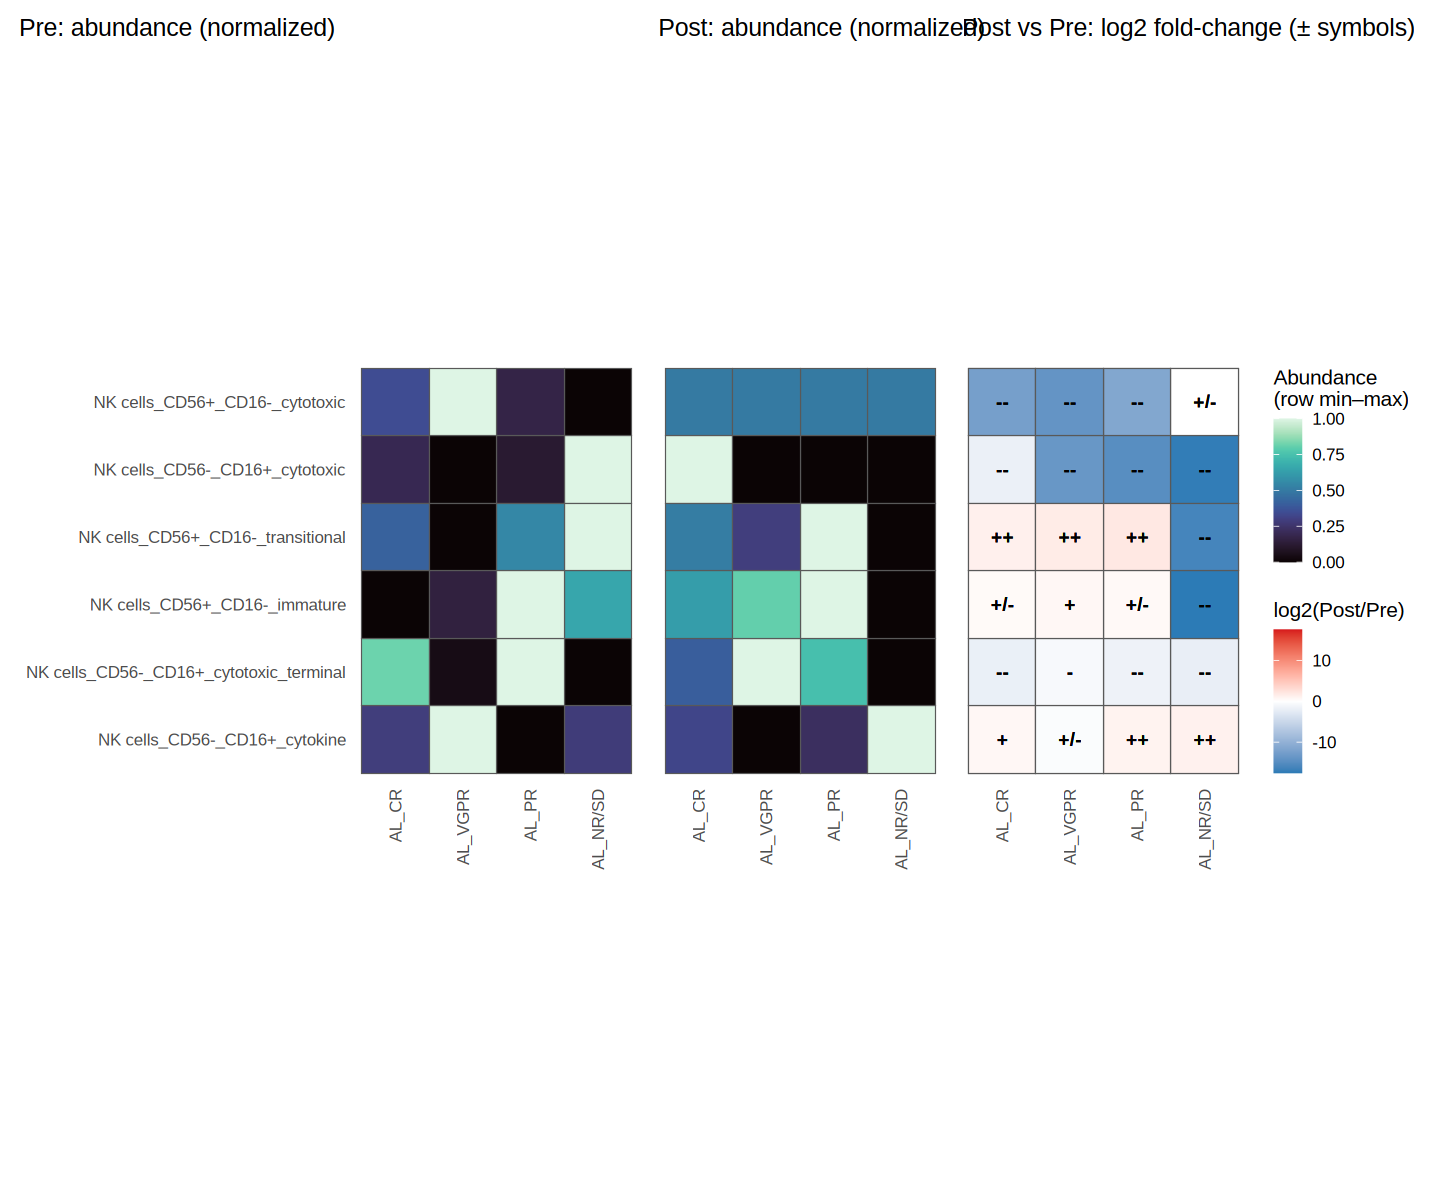

In [31]:
# --- after change_tbl is created (keep your previous wrangling) ---

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(patchwork)
  library(scales)
  library(viridis)
  library(viridisLite)
})

# Join LFC and symbols onto long table
frac_rtct2 <- frac_rtct %>%
  left_join(change_tbl %>% select(response, celltype, lfc, change_sym),
            by = c("response","celltype")) %>%
  mutate(
    response  = factor(response),
    celltype  = factor(celltype),
    treatment = factor(treatment, levels = c("Pre","Post"))
  )

# ---------------------------
# 1) Normalize abundance (pattern-focused)
#   - row-wise min-max within celltype x treatment
# ---------------------------
minmax01 <- function(x) {
  rng <- range(x, na.rm = TRUE)
  if (!all(is.finite(rng)) || diff(rng) == 0) return(rep(0.5, length(x)))
  (x - rng[1]) / (rng[2] - rng[1])
}

frac_rtct2 <- frac_rtct2 %>%
  group_by(celltype, treatment) %>%
  mutate(frac_norm = minmax01(frac)) %>%
  ungroup()

# ---------------------------
# 2) LFC cap (robust scale)
# ---------------------------
lfc_cap <- suppressWarnings(quantile(abs(frac_rtct2$lfc), 0.98, na.rm = TRUE))
if (!is.finite(lfc_cap) || lfc_cap == 0) {
  lfc_cap <- max(abs(frac_rtct2$lfc), na.rm = TRUE)
  if (!is.finite(lfc_cap) || lfc_cap == 0) lfc_cap <- 1
}

# ---------------------------
# 3) Paper-friendly MAK0 palette
#    Use viridisLite::mako to avoid version issues
# ---------------------------
mako_cols <- viridisLite::mako(256)

# ---------------------------
# Theme (vertical orientation)
# ---------------------------
vertical_theme <- theme_minimal(base_size = 12) +
  theme(
    axis.text.y  = element_text(angle = 0, hjust = 1, vjust = 0.5),
    axis.text.x  = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid   = element_blank(),
    plot.title.position = "plot"
  )

# ---------------------------
# 4) PRE normalized abundance heatmap (MAKO)
# ---------------------------
p_pre <- ggplot(
  subset(frac_rtct2, treatment == "Pre"),
  aes(x = response, y = celltype, fill = frac_norm)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradientn(
    name   = "Abundance\n(row min–max)",
    colors = mako_cols,
    limits = c(0, 1),
    oob    = scales::squish
  ) +
  coord_equal() +
  labs(title = "Pre: abundance (normalized)", x = NULL, y = NULL) +
  vertical_theme

# ---------------------------
# 5) POST normalized abundance heatmap (MAKO)
# ---------------------------
p_post <- ggplot(
  subset(frac_rtct2, treatment == "Post"),
  aes(x = response, y = celltype, fill = frac_norm)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradientn(
    name   = "Abundance\n(row min–max)",
    colors = mako_cols,
    limits = c(0, 1),
    oob    = scales::squish
  ) +
  coord_equal() +
  labs(title = "Post: abundance (normalized)", x = NULL, y = NULL) +
  vertical_theme +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank())

# ---------------------------
# 6) POST vs PRE (log2FC) with ± symbols (keep diverging for interpretability)
# ---------------------------
p_lfc <- ggplot(
  frac_rtct2,
  aes(x = response, y = celltype, fill = lfc)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradient2(
    name = "log2(Post/Pre)",
    low = "#2C7BB6", mid = "white", high = "#D7191C",
    midpoint = 0,
    limits = c(-lfc_cap, lfc_cap),
    oob = scales::squish
  ) +
  geom_text(
    data = subset(frac_rtct2, !is.na(change_sym)),
    aes(x = response, y = celltype, label = change_sym),
    inherit.aes = FALSE,
    color = "black", fontface = "bold", size = 4
  ) +
  coord_equal() +
  labs(title = "Post vs Pre: log2 fold-change (± symbols)", x = NULL, y = NULL) +
  vertical_theme +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank())

# ---------------------------
# 7) Combine horizontally
# ---------------------------
p_three <- (p_pre | p_post | p_lfc) +
  plot_layout(guides = "collect", widths = c(1, 1, 1)) &
  theme(legend.position = "right")

options(repr.plot.height = 10, repr.plot.width = 12)
print(p_three)


In [32]:
ggsave("Fig6b.pdf", plot = p_three, width = 10, height =12)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message 

In [33]:
# --- gene sets (same as your figure) ---
genes_inhib  <- c('KLRB1','TNFRSF18','KLRG1','TIGIT','KLRD1','CTLA4','HAVCR2','SIGLEC7','KLRD3','LILRB1','LILRB2','SIGLEC9')      # Inhibiting
genes_activ  <- c('KLRF1','FCGR3A','NCR3','ITGAL','CD2','CD226','NCR2','CD244','KLRK1','ICOS','CD96','TMIGD2','TNFRSF4','TNFRSF9','CD27','TNFRSF18') # Activating
genes_cytot  <- c('NKG7','GZMB','GNLY','FGFBP2','GZMH','PRF1','GZMA','FCGR3A','LAMP1','CST7','TNFSF10','FASLG')                  # Cytotoxicity
genes_cytok  <- c('CCL5','CCL4','CCL3','IFNG','TGFB1','IL10','IL1R1','IL1R2','IL15','IL16','IL18','IL32','CX3CR1','CXCR3','CXCR4','CXCR6','XCL1','XCL2','IL12RB2','CXCR6') # Cytokine



library(Seurat)
library(Matrix)

# Helper: per-cell mean on the log-normalized "data" slot
mean_score <- function(obj, genes, slot = "data") {
  g <- intersect(genes, rownames(obj))
  if (length(g) == 0) return(rep(NA_real_, ncol(obj)))
  mat <- GetAssayData(obj, slot = slot)[g, , drop = FALSE]
  Matrix::colMeans(mat)  # mean(log1p CPM) across the set
}

# Compute scores
sce1_nkcell$score_inhibiting   <- mean_score(sce1_nkcell, genes_inhib)
sce1_nkcell$score_activating   <- mean_score(sce1_nkcell, genes_activ)
sce1_nkcell$score_cytotoxicity <- mean_score(sce1_nkcell, genes_cytot)
sce1_nkcell$score_cytokine     <- mean_score(sce1_nkcell, genes_cytok)


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


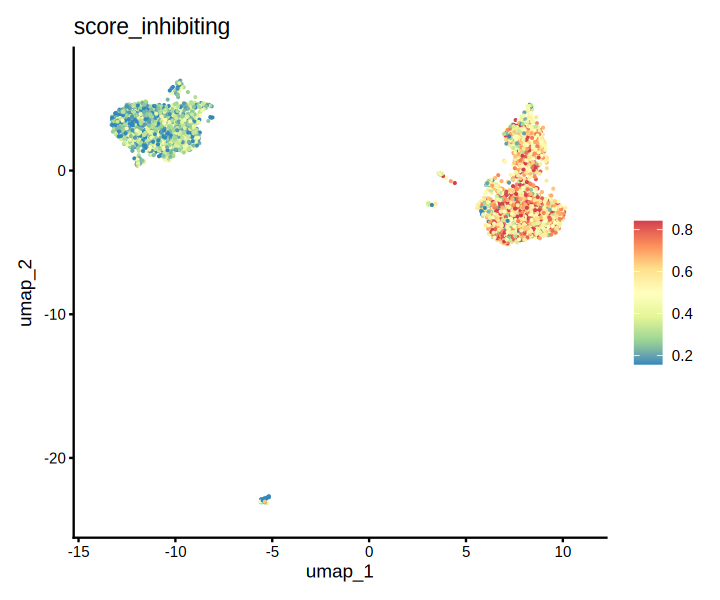

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


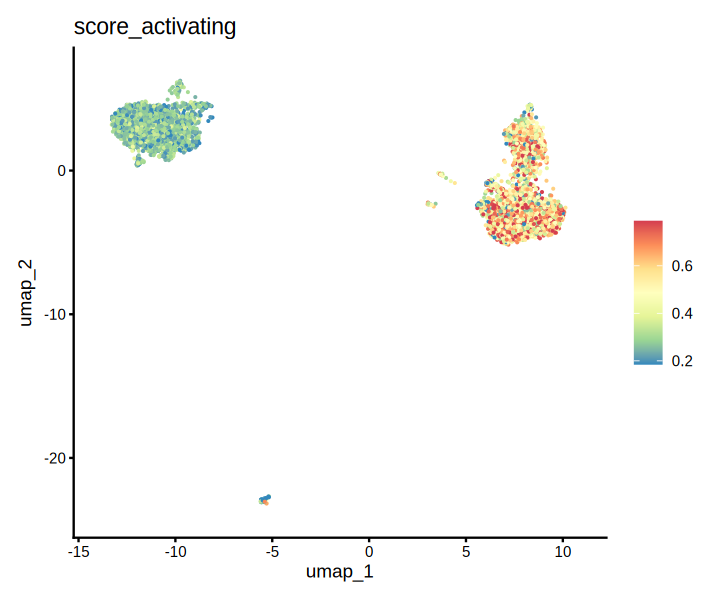

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


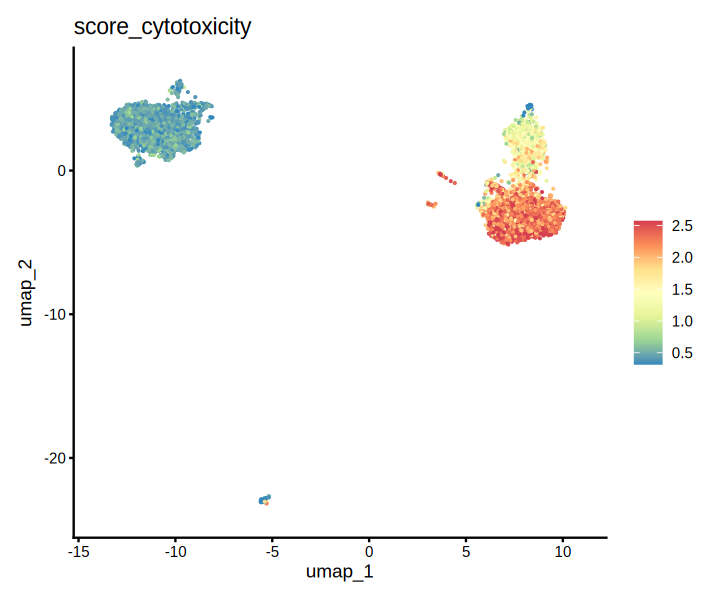

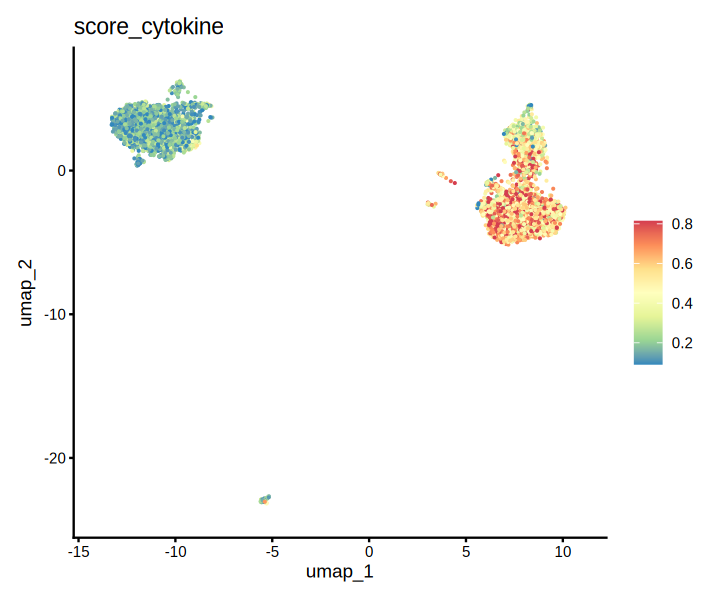

In [34]:
library(Seurat)
library(RColorBrewer)

options(repr.plot.height = 5, repr.plot.width = 6)

# --- Define color palette ---
spectral_colors <- brewer.pal(11, "Spectral")  # 11-step Spectral palette

# --- FeaturePlot with Spectral palette ---
FeaturePlot(
  sce1_nkcell,
  features = c("score_inhibiting"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()

FeaturePlot(
  sce1_nkcell,
  features = c( "score_activating"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()
FeaturePlot(
  sce1_nkcell,
  features = c("score_cytotoxicity"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()
FeaturePlot(
  sce1_nkcell,
  features = c("score_cytokine"),
  min.cutoff = "q5", max.cutoff = "q95", pt.size = 0.1,reduction='umap',
) + 
  scale_color_distiller(palette = "Spectral") +
  theme_classic()

In [35]:
Idents(sce1_nkcell)<-'Annotation'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene<- c(
"CD38",'PTGS2','PTGER2','PTGER4','PTGES2','PTGES3','KLRK1','LILRB1','HCST'
) 


## 10. Visualization and figure generation


In [36]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_nkcell, features = unique(allgene), split.by = "Annotation", scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


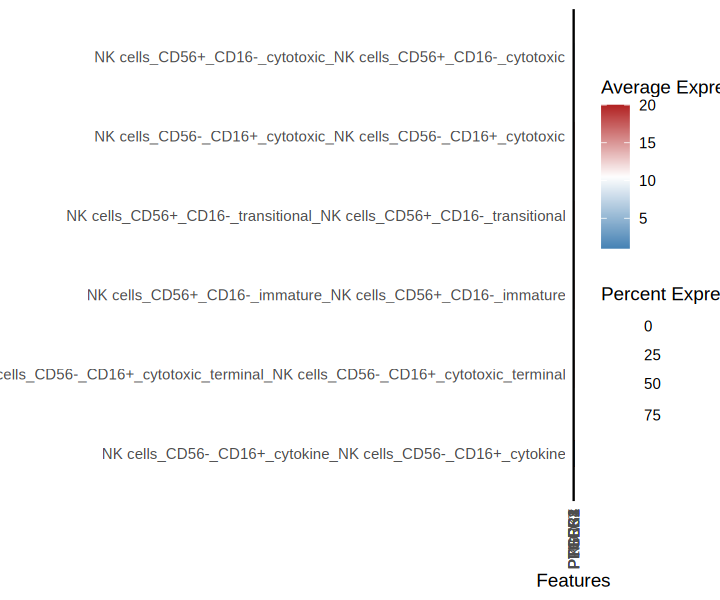

In [37]:
# 1) Define the exact order you want (top -> bottom)
row_order <- rev(unique(plot_data$id)[c(6,3,5,1,4,2)])
# 2) Apply it (this controls ggplot row order)
plot_data$id <- factor(plot_data$id, levels = row_order)

# 3) Plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled),
             shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [38]:
ggsave("Fig6c.pdf", plot = p, width = 9, height =4)

## 11. Load utility functions


In [39]:
# Load utility functions
source("enrichment_utils_C5.R")


# Change this for each dataset
obj <- sce1_nkcell

# Assay/layer
assay_use <- DefaultAssay(obj)
layer_use <- "data"

# Metadata columns in obj@meta.data
celltype_col <- "Annotation"   # e.g. "Annotation" or "predicted_CellType"
treat_col    <- "treatment"     # expected values: "Pre", "Post"
resp_col     <- "response"      # e.g. "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD"

# Response grouping
good_set <- c("AL_CR", "AL_VGPR")
poor_set <- c("AL_PR", "AL_NR/SD")

# Optional cell type order for heatmap x-axis
celltype_order <- unique(obj@meta.data[[celltype_col]])


# Change only these regex terms for each biological question
focus_regex <- "(INTERFERON)"
C2_regex <- paste(c("NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY", "FCGR", "FCGAMMA",
    "FCERI", "FCE_RI", "FCER1", "ADCC"  ), collapse = "|")
C7_regex <- paste(c("NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY", "FCGR", "FCGAMMA",
    "FCERI", "FCE_RI", "FCER1", "ADCC"  ), collapse = "|")
C5_regex <- paste(c("NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY", "FCGR", "FCGAMMA",
    "FCERI", "FCE_RI", "FCER1", "ADCC"  ), collapse = "|")

res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  # output
  out_dir = "./results/nkcell_INTERFERON_PROGENy_ssGSEA"
)


# Per-cell PROGENy and ssGSEA scores
head(res$all_cell_scores)

# Post vs Pre within Good/Poor response groups
head(res$post_vs_pre_delta)

# Poor vs Good within Pre/Post treatment groups
head(res$poor_vs_good_delta)

# Output file paths
res$output_files




Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“142 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 20 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <a2>

Method,cell_id,Annotation,treatment,response,resp_group,pathway,score_raw,score_z
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
PROGENy,ALl14_AAAGGTAAGCATCGAG-1,NK cells_CD56+_CD16-_immature,Pre,AL_CR,Good,Hypoxia,-0.1859948,-0.1809312
PROGENy,ALl14_AAAGGTAAGCATCGAG-1,NK cells_CD56+_CD16-_immature,Pre,AL_CR,Good,JAK-STAT,-0.9505727,-0.9481645
PROGENy,ALl14_AAAGGTAAGCATCGAG-1,NK cells_CD56+_CD16-_immature,Pre,AL_CR,Good,NFkB,-0.8084091,-0.8111370
PROGENy,ALl14_AAAGGTAAGCATCGAG-1,NK cells_CD56+_CD16-_immature,Pre,AL_CR,Good,TGFb,-1.1250339,-1.0974865
PROGENy,ALl14_AAAGGTAAGCATCGAG-1,NK cells_CD56+_CD16-_immature,Pre,AL_CR,Good,TNFa,-0.8627496,-0.8692954
PROGENy,ALl14_AACAGGGTCTTCGTGC-1,NK cells_CD56-_CD16+_cytokine,Pre,AL_CR,Good,Hypoxia,-0.4338577,-0.4299770


Method,contrast,Annotation,response_group,pathway,n_pre,n_post,mean_pre,mean_post,deltaNES,p_value,padj,star
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Post_vs_Pre_within_response,NK cells_CD56+_CD16-_immature,Good,Hypoxia,236,89,-0.2243546,-0.36734331,-0.1429887,0.409893241,0.409893241,
PROGENy,Post_vs_Pre_within_response,NK cells_CD56+_CD16-_immature,Good,JAK-STAT,236,89,-0.5795127,-0.42180934,0.1577034,0.146251871,0.146251871,
PROGENy,Post_vs_Pre_within_response,NK cells_CD56+_CD16-_immature,Good,NFkB,236,89,-0.5353176,-0.72362909,-0.1883115,0.056353126,0.056353126,
PROGENy,Post_vs_Pre_within_response,NK cells_CD56+_CD16-_immature,Good,TGFb,236,89,-0.1843156,-0.50935226,-0.3250367,0.006175142,0.006175142,**
PROGENy,Post_vs_Pre_within_response,NK cells_CD56+_CD16-_immature,Good,TNFa,236,89,-0.4877618,-0.74154551,-0.2537837,0.008848170,0.008848170,**
PROGENy,Post_vs_Pre_within_response,NK cells_CD56+_CD16-_immature,Poor,Hypoxia,195,29,-0.5002210,0.02699273,0.5272138,0.004907295,0.009814590,**


Method,contrast,Annotation,treatment_group,pathway,n_good,n_poor,mean_good,mean_poor,deltaNES,p_value,padj,star
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Poor_vs_Good_within_treatment,NK cells_CD56+_CD16-_cytotoxic,Pre,Hypoxia,4,1,0.8209616,-1.92479269,-2.7457543,NA,NA,
PROGENy,Poor_vs_Good_within_treatment,NK cells_CD56+_CD16-_cytotoxic,Pre,JAK-STAT,4,1,0.3004882,-0.51836104,-0.8188493,NA,NA,
PROGENy,Poor_vs_Good_within_treatment,NK cells_CD56+_CD16-_cytotoxic,Pre,NFkB,4,1,1.3923029,0.04817683,-1.3441261,NA,NA,
PROGENy,Poor_vs_Good_within_treatment,NK cells_CD56+_CD16-_cytotoxic,Pre,TGFb,4,1,0.6128888,-0.19522176,-0.8081105,NA,NA,
PROGENy,Poor_vs_Good_within_treatment,NK cells_CD56+_CD16-_cytotoxic,Pre,TNFa,4,1,1.3491251,-0.14758171,-1.4967068,NA,NA,
PROGENy,Poor_vs_Good_within_treatment,NK cells_CD56+_CD16-_immature,Post,Hypoxia,89,29,-0.3673433,0.02699273,0.3943360,0.05342844,0.05342844,


$gene_sets_txt
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/ssgsea_gene_sets_used.txt"

$all_cell_scores_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/all_cell_scores_PROGENy_ssGSEA.csv.gz"

$post_vs_pre_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Post_vs_Pre_within_GoodPoor.csv.gz"

$poor_vs_good_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Poor_vs_Good_within_PrePost.csv.gz"

$all_delta_scores_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/all_delta_scores_two_contrasts_PROGENy_ssGSEA.csv.gz"

$heatmap_post_vs_pre_pdf
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.pdf"

$heatmap_post_vs_pre_png
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.png"

$heatmap_poor_vs_good_pdf
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.pdf"

$heatmap_poor_vs_good_png
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.png"

In [47]:
# ------------------------------------------------------------
# Read IFN/interferon gene signatures from CSV
# Each column = one signature
# Column name = signature name
# Non-empty values in that column = genes
# ------------------------------------------------------------

ifn_gene_df <- read.csv(
  "intergerongenes.csv",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

custom_ifn_gene_sets <- lapply(ifn_gene_df, function(genes) {
  genes <- trimws(as.character(genes))
  genes <- genes[!is.na(genes) & genes != ""]
  unique(genes)
})

# Optional checks
names(custom_ifn_gene_sets)
str(custom_ifn_gene_sets)
# Optional: keep only genes present in this Seurat object
genes_present <- rownames(obj)

custom_ifn_gene_sets <- lapply(custom_ifn_gene_sets, function(x) {
  unique(intersect(x, genes_present))
})

# Keep one-gene sets because TNK_IFNAB_SPECIFIC and TNK_IFNG_SPECIFIC are biologically intentional.
custom_ifn_gene_sets <- custom_ifn_gene_sets[lengths(custom_ifn_gene_sets) >= 1]

message("Custom IFN gene sets retained:")
print(sapply(custom_ifn_gene_sets, length))

[1] "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING"
[2] "REACTOME_INTERFERON_GAMMA_SIGNALING"     
[3] "BIOCARTA_IFNA_PATHWAY"                   
[4] "BIOCARTA_IFNG_PATHWAY"

List of 4
 $ REACTOME_INTERFERON_ALPHA_BETA_SIGNALING: chr [1:78] "ABCE1" "ADAR" "BST2" "EGR1" ...
 $ REACTOME_INTERFERON_GAMMA_SIGNALING     : chr [1:98] "B2M" "CAMK2A" "CAMK2B" "CAMK2D" ...
 $ BIOCARTA_IFNA_PATHWAY                   : chr [1:9] "IFNA1" "IFNAR1" "IFNAR2" "IFNB1" ...
 $ BIOCARTA_IFNG_PATHWAY                   : chr [1:6] "IFNG" "IFNGR1" "IFNGR2" "JAK1" ...


Custom IFN gene sets retained:



REACTOME_INTERFERON_ALPHA_BETA_SIGNALING 
                                      77 
     REACTOME_INTERFERON_GAMMA_SIGNALING 
                                      94 
                   BIOCARTA_IFNA_PATHWAY 
                                       9 
                   BIOCARTA_IFNG_PATHWAY 
                                       6 


In [48]:
source("enrichment_utils_C5_custom_IFN.R")

res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  # Custom IFN gene sets
  custom_gene_sets = custom_ifn_gene_sets,
  custom_gene_set_prefix = "CUSTOM_IFN",
  min_genes_per_custom_set = 1,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  out_dir = "./results/nkcell_INTERFERON_PROGENy_ssGSEA"
)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Added custom gene sets: CUSTOM_IFN_REACTOME_INTERFERON_ALPHA_BETA_SIGNALING, CUSTOM_IFN_REACTOME_INTERFERON_GAMMA_SIGNALING, CUSTOM_IFN_BIOCARTA_IFNA_PATHWAY, CUSTOM_IFN_BIOCARTA_IFNG_PATHWAY

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“148 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 24 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_GAMMA_RESPONSE' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_GAMMA_RESPONSE' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_GAMMA_RESPONSE' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_ALPHA_RESPONSE' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_ALPHA_RESPONSE' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C

In [42]:
source("enrichment_utils_C5_custom_PGE.R")
res_ptger <- run_receptor_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("PTGER2", "PTGER4"),
  species = "Homo sapiens",

  # default is now High PTGER2/PTGER4 vs Low PTGER2/PTGER4
  contrast_group1 = NULL,
  contrast_group2 = NULL,

  # default uses focused EP2/EP4 downstream + immune-program regex
  enrichment_focus_regex = NULL,

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 30,
  top_n_deg = 10,

  out_dir = "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell"
)

head(res_ptger$ssgsea_stats)
head(res_ptger$pseudobulk_deg)
res_ptger$output_files

Focused gene sets retained: 12

Examples: HALLMARK_ALLOGRAFT_REJECTION | HALLMARK_APICAL_JUNCTION | HALLMARK_IL2_STAT5_SIGNALING | HALLMARK_INFLAMMATORY_RESPONSE | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | HALLMARK_MTORC1_SIGNALING | HALLMARK_MYC_TARGETS_V1 | HALLMARK_MYC_TARGETS_V2 | HALLMARK_OXIDATIVE_PHOSPHORYLATION | HALLMARK_PI3K_AKT_MTOR_SIGNALING | HALLMARK_TNFA_SIGNALING_VIA_NFKB

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“77 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 12 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_text()`).”
sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High PTGER2/PTGER4 - Low PTGER2/PTGER4

Done. Output directory: ./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NK cells_CD56-_CD16+_cytokine,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Low PTGER2/PTGER4,High PTGER2/PTGER4,341,340,1.21293697,0.56827491,-0.6446621,2.846446e-21,3.415735e-20,***,OXIDATIVE PHOSPHORYLATION,Up in Low PTGER2/PTGER4
NK cells_CD56-_CD16+_cytokine,HALLMARK_MYC_TARGETS_V1,Low PTGER2/PTGER4,High PTGER2/PTGER4,341,340,0.85198571,0.13008087,-0.7219048,3.297814e-19,1.978689e-18,***,MYC TARGETS V1,Up in Low PTGER2/PTGER4
NK cells_CD56-_CD16+_cytokine,HALLMARK_INFLAMMATORY_RESPONSE,Low PTGER2/PTGER4,High PTGER2/PTGER4,341,340,-0.07419381,0.57389868,0.6480925,5.366125e-15,2.146450e-14,***,INFLAMMATORY RESPONSE,Up in High PTGER2/PTGER4
NK cells_CD56-_CD16+_cytotoxic_terminal,HALLMARK_MYC_TARGETS_V1,Low PTGER2/PTGER4,High PTGER2/PTGER4,236,235,0.13760461,-0.39224286,-0.5298475,5.921925e-13,7.106310e-12,***,MYC TARGETS V1,Up in Low PTGER2/PTGER4
NK cells_CD56-_CD16+_cytokine,HALLMARK_APICAL_JUNCTION,Low PTGER2/PTGER4,High PTGER2/PTGER4,341,340,-0.80279647,-0.29234228,0.5104542,3.734209e-11,1.120263e-10,***,APICAL JUNCTION,Up in High PTGER2/PTGER4
NK cells_CD56-_CD16+_cytotoxic_terminal,HALLMARK_INFLAMMATORY_RESPONSE,Low PTGER2/PTGER4,High PTGER2/PTGER4,236,235,-0.60395521,-0.07239564,0.5315596,2.935243e-11,1.761146e-10,***,INFLAMMATORY RESPONSE,Up in High PTGER2/PTGER4


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NK cells_CD56+_CD16-_immature,MIR1302-2HG,Low PTGER2/PTGER4,High PTGER2/PTGER4,43,43,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,FAM138A,Low PTGER2/PTGER4,High PTGER2/PTGER4,43,43,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,OR4F5,Low PTGER2/PTGER4,High PTGER2/PTGER4,43,43,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.1,Low PTGER2/PTGER4,High PTGER2/PTGER4,43,43,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.3,Low PTGER2/PTGER4,High PTGER2/PTGER4,43,43,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.2,Low PTGER2/PTGER4,High PTGER2/PTGER4,43,43,1,1,0,0,0,NA,NA


$meta_receptor_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_nkcell/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

In [46]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("IFNAR1", "IFNAR2"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“48 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_text()`).”
sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High IFNAR1/IFNAR2 - Low IFNAR1/IFNAR2

Done. Output directory: ./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NK cells_CD56-_CD16+_cytokine,BIOCARTA_IFNA_PATHWAY,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,379,378,0.4199335,1.3345847,0.9146512,3.120402e-43,3.432442e-42,***,BIOCARTA IFNA PATHWAY,Up in High IFNAR1/IFNAR2
NK cells_CD56-_CD16+_cytokine,REACTOME_REGULATION_OF_IFNA_SIGNALING,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,379,378,0.1176589,1.0605179,0.9428591,3.221258e-38,1.771692e-37,***,REACTOME REGULATION OF IFNA SIGNALING,Up in High IFNAR1/IFNAR2
NK cells_CD56-_CD16+_cytokine,KEGG_JAK_STAT_SIGNALING_PATHWAY,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,379,378,-1.0698849,-0.5419135,0.5279713,8.656559e-15,3.174072e-14,***,KEGG JAK STAT SIGNALING PATHWAY,Up in High IFNAR1/IFNAR2
NK cells_CD56-_CD16+_cytotoxic_terminal,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,166,165,0.0116876,-0.5148890,-0.5265766,2.206378e-08,2.427016e-07,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
NK cells_CD56+_CD16-_immature,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,0.3281312,-0.4574837,-0.7856149,3.269628e-08,3.596591e-07,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
NK cells_CD56-_CD16+_cytotoxic_terminal,HALLMARK_INTERFERON_GAMMA_RESPONSE,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,166,165,-0.2604126,-0.6291820,-0.3687694,7.161809e-08,3.938995e-07,***,INTERFERON GAMMA RESPONSE,Up in Low IFNAR1/IFNAR2


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NK cells_CD56+_CD16-_immature,MIR1302-2HG,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,1,1,0.00000000,0,0.00000000,NA,NA
NK cells_CD56+_CD16-_immature,FAM138A,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,1,1,0.00000000,0,0.00000000,NA,NA
NK cells_CD56+_CD16-_immature,OR4F5,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,1,1,0.00000000,0,0.00000000,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.1,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,1,1,0.01443204,0,-0.01443204,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.3,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,1,1,0.00000000,0,0.00000000,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.2,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,73,72,1,1,0.00000000,0,0.00000000,NA,NA


$meta_receptor_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell1/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

## 12. Pathway and gene-set enrichment


In [45]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("IFNGR1", "IFNGR2"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“48 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_text()`).”
sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High IFNGR1/IFNGR2 - Low IFNGR1/IFNGR2

Done. Output directory: ./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NK cells_CD56-_CD16+_cytokine,BIOCARTA_IFNG_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,494,493,0.39272633,1.5490555,1.1563291,3.142947e-100,3.457242e-99,***,BIOCARTA IFNG PATHWAY,Up in High IFNGR1/IFNGR2
NK cells_CD56-_CD16+_cytokine,REACTOME_REGULATION_OF_IFNG_SIGNALING,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,494,493,0.59425949,1.0448364,0.4505769,7.016599e-18,3.859129e-17,***,REACTOME REGULATION OF IFNG SIGNALING,Up in High IFNGR1/IFNGR2
NK cells_CD56-_CD16+_cytokine,HALLMARK_IL6_JAK_STAT3_SIGNALING,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,494,493,0.40197781,0.8065392,0.4045614,3.730352e-09,1.367796e-08,***,IL6 JAK STAT3 SIGNALING,Up in High IFNGR1/IFNGR2
NK cells_CD56-_CD16+_cytotoxic_terminal,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,129,129,0.02803784,-0.4839425,-0.5119804,4.758056e-07,5.208777e-06,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNGR1/IFNGR2
NK cells_CD56-_CD16+_cytotoxic_terminal,KEGG_JAK_STAT_SIGNALING_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,129,129,0.36631773,0.7628265,0.3965088,9.470504e-07,5.208777e-06,***,KEGG JAK STAT SIGNALING PATHWAY,Up in High IFNGR1/IFNGR2
NK cells_CD56-_CD16+_cytokine,KEGG_JAK_STAT_SIGNALING_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,494,493,-0.96914700,-0.6897718,0.2793752,2.416624e-06,6.645716e-06,***,KEGG JAK STAT SIGNALING PATHWAY,Up in High IFNGR1/IFNGR2


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NK cells_CD56+_CD16-_immature,MIR1302-2HG,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,31,31,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,FAM138A,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,31,31,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,OR4F5,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,31,31,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.1,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,31,31,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.3,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,31,31,1,1,0,0,0,NA,NA
NK cells_CD56+_CD16-_immature,AL627309.2,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,31,31,1,1,0,0,0,NA,NA


$meta_receptor_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_nkcell2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"